In [1]:
!pip install -q \
    "pydicom" \
    "timm" \
    "pylibjpeg" \
    "pylibjpeg-libjpeg" \
    "pylibjpeg-openjpeg" \
    "python-gdcm" \
    "flwr==1.33.0" \
    "opacus==1.5.2"

In [2]:
!pip install -U "protobuf>=6.33.6,<7"

In [3]:
!pip install -q --no-cache-dir --force-reinstall "numpy==1.26.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 343.5 MB/s eta 0:00:00 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is i

In [4]:
import google.protobuf

print("Protobuf version:", google.protobuf.__version__)

Protobuf version: 6.33.6


In [5]:
import numpy as np
import torch
import opacus
import flwr

print("NumPy :", np.__version__)
print("PyTorch:", torch.__version__)
print("Opacus:", opacus.__version__)
print("Flower:", flwr.__version__)

NumPy : 1.26.4
PyTorch: 2.10.0+cu128
Opacus: 1.5.2
Flower: 1.33.0


In [6]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import zipfile
import shutil
import random
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm

import pydicom

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


In [7]:
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def make_retrying_session(total=5, backoff_factor=2, status_forcelist=(500, 502, 503, 504)):
    """A requests.Session that retries transient failures with exponential backoff --
    reused by every TCIA/NBIA call in this notebook (tabular fetch, getSeries, getImage)."""
    session = requests.Session()
    retry = Retry(total=total, backoff_factor=backoff_factor,
                   status_forcelist=status_forcelist, allowed_methods=frozenset(['GET']))
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('https://', adapter)
    session.mount('http://', adapter)
    return session

_SESSION = make_retrying_session()

try:
    _test = _SESSION.get("https://services.cancerimagingarchive.net/nbia-api/services/v1/getCollectionValues",
                          timeout=20)
    print(f"Network OK -- reached cancerimagingarchive.net (status {_test.status_code}).")
except requests.exceptions.RequestException as e:
    print("Could NOT reach cancerimagingarchive.net.")
    print(f"  {type(e).__name__}: {str(e)[:200]}")
    print()
    print("On Kaggle: Settings -> Internet -> turn ON (needs phone verification once), then re-run this cell.")
    print("If Internet is already on, TCIA may be temporarily slow -- just re-run the download cells below.")


Network OK -- reached cancerimagingarchive.net (status 200).


In [8]:
# --- Kaggle folder layout ---
# Nothing raw (xlsx / DICOM zips) ever touches disk -- everything is fetched
# straight into memory with `requests` + `io.BytesIO`. Only small derived
# outputs (preprocessed 224x224 .npy, hospital splits, checkpoints) are saved.
BASE_DIR       = Path('/kaggle/working/duke_breast_cancer')
PROCESSED_DIR  = BASE_DIR / 'processed'
SPLIT_DIR      = BASE_DIR / 'hospital_splits'
CHECKPOINT_DIR = BASE_DIR / 'checkpoints'

for d in [BASE_DIR, PROCESSED_DIR, SPLIT_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Directory structure ready:")
for name, d in [('Base', BASE_DIR), ('Processed', PROCESSED_DIR),
                 ('Splits', SPLIT_DIR), ('Checkpoints', CHECKPOINT_DIR)]:
    print(f"   {name:16s}: {d}")

def show_disk_usage(path='/kaggle/working'):
    total, used, free = shutil.disk_usage(path)
    print(f"Disk @ {path}:  used {used/1e9:6.2f} GB  |  free {free/1e9:6.2f} GB  |  total {total/1e9:6.2f} GB")

show_disk_usage()


Directory structure ready:
   Base            : /kaggle/working/duke_breast_cancer
   Processed       : /kaggle/working/duke_breast_cancer/processed
   Splits          : /kaggle/working/duke_breast_cancer/hospital_splits
   Checkpoints     : /kaggle/working/duke_breast_cancer/checkpoints
Disk @ /kaggle/working:  used   0.92 GB  |  free  20.03 GB  |  total  20.96 GB


In [9]:
TABULAR_URLS = {
    'clinical':   'https://www.cancerimagingarchive.net/wp-content/uploads/Clinical_and_Other_Features.xlsx',
    'imaging':    'https://www.cancerimagingarchive.net/wp-content/uploads/Imaging_Features.xlsx',
    'annotation': 'https://www.cancerimagingarchive.net/wp-content/uploads/Annotation_Boxes.xlsx',
}

def fetch_excel(url, timeout=120, **read_excel_kwargs):
    """Streams an .xlsx straight into a DataFrame -- nothing is ever written to disk,
    same pattern as the getSeries JSON call above. Uses the retrying `_SESSION` from
    Section 1a so transient TCIA slowness doesn't kill the whole run."""
    try:
        resp = _SESSION.get(url, timeout=timeout)
        resp.raise_for_status()
    except requests.exceptions.RequestException as e:
        raise RuntimeError(
            f"Could not fetch {url}\n"
            f"  {type(e).__name__}: {str(e)[:200]}\n"
            f"  -> On Kaggle, check Settings -> Internet is ON, then re-run this cell."
        ) from e
    return pd.read_excel(io.BytesIO(resp.content), **read_excel_kwargs)

print("fetch_excel() ready -- reads directly from TCIA into memory.")


fetch_excel() ready -- reads directly from TCIA into memory.


In [10]:
# The clinical file's real header row is row index 1 (row 0 is a title/merged-cell row).
df_clinical   = fetch_excel(TABULAR_URLS['clinical'], header=1)
df_imaging    = fetch_excel(TABULAR_URLS['imaging'])
df_annotation = fetch_excel(TABULAR_URLS['annotation'])   # tumor-location boxes, kept for completeness

PATIENT_ID_COL = 'Patient ID'
SUBTYPE_COL    = 'Mol Subtype'
PCR_COL        = 'Pathologic Response to Neoadjuvant Therapy'

print(f"Clinical Features  : {df_clinical.shape}")
print(f"Imaging Features   : {df_imaging.shape}")
print(f"Annotation Boxes   : {df_annotation.shape}")
print()
print(df_clinical[SUBTYPE_COL].value_counts())


Clinical Features  : (923, 98)
Imaging Features   : (922, 530)
Annotation Boxes   : (922, 7)

Mol Subtype
0                                                                         595
3                                                                         164
1                                                                         104
2                                                                          59
{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}      1
Name: count, dtype: int64


In [11]:
N_PATIENTS = 922   # set to 922 for the full collection
selected_csv = BASE_DIR / 'selected_patients.csv'
if selected_csv.exists():
    df_selected = pd.read_csv(selected_csv)
    le = LabelEncoder()
    le.fit(df_selected[SUBTYPE_COL].astype(str))
    print(f"Loaded existing patient selection: {len(df_selected)} patients")
else:
    df_valid = df_clinical.dropna(subset=[SUBTYPE_COL, PATIENT_ID_COL]).copy()
    print(f"Valid patients (have subtype label): {len(df_valid)}")
    le = LabelEncoder()
    df_valid['subtype_label'] = le.fit_transform(df_valid[SUBTYPE_COL].astype(str))
    print(f"Label classes: {list(le.classes_)}")

    if N_PATIENTS >= len(df_valid):
        # পুরো valid dataset-ই নেওয়া হচ্ছে, split-এর দরকার নেই
        df_selected = df_valid.copy()
    else:
        df_selected, _ = train_test_split(
            df_valid, train_size=N_PATIENTS,
            stratify=df_valid['subtype_label'], random_state=42
        )

    df_selected.to_csv(selected_csv, index=False)
    print(f"Saved: {selected_csv}")

selected_patient_ids = df_selected[PATIENT_ID_COL].tolist()
print(f"\nSelected {len(df_selected)} patients")
print(df_selected[SUBTYPE_COL].value_counts())

Loaded existing patient selection: 922 patients

Selected 922 patients
Mol Subtype
0    595
3    164
1    104
2     59
Name: count, dtype: int64


In [12]:
series_csv = BASE_DIR / 'series_list.csv'

if series_csv.exists():
    print("Series list already exists, loading from cache...")
    df_series = pd.read_csv(series_csv)
else:
    url = "https://services.cancerimagingarchive.net/nbia-api/services/v1/getSeries"
    params = {
        "Collection": "Duke-Breast-Cancer-MRI",
        "format": "json"
    }

    try:
        response = _SESSION.get(url, params=params, timeout=120)
        print("Status:", response.status_code)
        print("Content-Type:", response.headers.get("Content-Type"))
    except requests.exceptions.RequestException as e:
        raise RuntimeError(
            f"Could not reach {url}\n"
            f"  {type(e).__name__}: {str(e)[:200]}\n"
            f"  -> On Kaggle, check Settings -> Internet is ON, then re-run this cell."
        ) from e

    data = response.json()
    df_series = pd.DataFrame(data)
    df_series.to_csv(series_csv, index=False)
    print(f"Series list saved: {series_csv}")

print("\nTotal series:", len(df_series))
print("Total patients:", df_series["PatientID"].nunique())
print("\nShape:", df_series.shape)
print("\nColumns:", df_series.columns.tolist())
df_series.head()


Series list already exists, loading from cache...

Total series: 5161
Total patients: 922

Shape: (5161, 22)

Columns: ['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDate', 'SeriesDescription', 'BodyPartExamined', 'SeriesNumber', 'Collection', 'PatientID', 'Manufacturer', 'ManufacturerModelName', 'SoftwareVersions', 'ImageCount', 'TimeStamp', 'LicenseName', 'LicenseURI', 'CollectionURI', 'FileSize', 'DateReleased', 'StudyDesc', 'StudyDate', 'ThirdPartyAnalysis']


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,...,ImageCount,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDesc,StudyDate,ThirdPartyAnalysis
0,1.3.6.1.4.1.14519.5.2.1.1571934354247260547776...,1.3.6.1.4.1.14519.5.2.1.3690687164171616178473...,MR,1990-01-01 00:00:00.0,1st ax dyn,BREAST,6,Duke-Breast-Cancer-MRI,Breast_MRI_299,GE MEDICAL SYSTEMS,...,96,2020-08-20 12:37:30.0,Creative Commons Attribution-NonCommercial 4.0...,https://creativecommons.org/licenses/by-nc/4.0/,https://doi.org/10.7937/TCIA.e3sv-re93,50548156,2021-04-06 00:00:00.0,MRI BREAST BILATERAL W + W/O,1990-01-01 00:00:00.0,NO
1,1.3.6.1.4.1.14519.5.2.1.2182165295830490194804...,1.3.6.1.4.1.14519.5.2.1.3690687164171616178473...,MR,1990-01-01 00:00:00.0,ax 3d pre,BREAST,5,Duke-Breast-Cancer-MRI,Breast_MRI_299,GE MEDICAL SYSTEMS,...,96,2020-08-20 12:37:53.0,Creative Commons Attribution-NonCommercial 4.0...,https://creativecommons.org/licenses/by-nc/4.0/,https://doi.org/10.7937/TCIA.e3sv-re93,50544858,2021-04-06 00:00:00.0,MRI BREAST BILATERAL W + W/O,1990-01-01 00:00:00.0,NO
2,1.3.6.1.4.1.14519.5.2.1.2203250100100201085757...,1.3.6.1.4.1.14519.5.2.1.3690687164171616178473...,MR,1990-01-01 00:00:00.0,4th ax dyn,BREAST,10,Duke-Breast-Cancer-MRI,Breast_MRI_299,GE MEDICAL SYSTEMS,...,96,2020-08-20 12:38:11.0,Creative Commons Attribution-NonCommercial 4.0...,https://creativecommons.org/licenses/by-nc/4.0/,https://doi.org/10.7937/TCIA.e3sv-re93,50548140,2021-04-06 00:00:00.0,MRI BREAST BILATERAL W + W/O,1990-01-01 00:00:00.0,NO
3,1.3.6.1.4.1.14519.5.2.1.3154536356895736396506...,1.3.6.1.4.1.14519.5.2.1.3690687164171616178473...,MR,1990-01-01 00:00:00.0,AX IDEAL Breast,BREAST,904,Duke-Breast-Cancer-MRI,Breast_MRI_299,GE MEDICAL SYSTEMS,...,29,2020-08-20 12:38:15.0,Creative Commons Attribution-NonCommercial 4.0...,https://creativecommons.org/licenses/by-nc/4.0/,https://doi.org/10.7937/TCIA.e3sv-re93,15268496,2021-04-06 00:00:00.0,MRI BREAST BILATERAL W + W/O,1990-01-01 00:00:00.0,NO
4,1.3.6.1.4.1.14519.5.2.1.3317219596622139366312...,1.3.6.1.4.1.14519.5.2.1.3690687164171616178473...,MR,1990-01-01 00:00:00.0,3rd ax dyn,BREAST,8,Duke-Breast-Cancer-MRI,Breast_MRI_299,GE MEDICAL SYSTEMS,...,96,2020-08-20 12:38:26.0,Creative Commons Attribution-NonCommercial 4.0...,https://creativecommons.org/licenses/by-nc/4.0/,https://doi.org/10.7937/TCIA.e3sv-re93,50548096,2021-04-06 00:00:00.0,MRI BREAST BILATERAL W + W/O,1990-01-01 00:00:00.0,NO


In [13]:
# Same exploration as your original notebook
print("Number of unique SeriesDescription:", df_series["SeriesDescription"].nunique())
print("\nAll SeriesDescription values:")
for x in sorted(df_series["SeriesDescription"].dropna().unique()):
    print(x)



Number of unique SeriesDescription: 58

All SeriesDescription values:
1st ax dyn
2nd ax dyn
3rd ax dyn
4th ax dyn
AX IDEAL Breast
Ax 3D T1 NON FS
Ax Vibrant MultiPhase
Ph1/Ax Vibrant MultiPhase
Ph1/ax 3d dyn
Ph1/ax 3d dyn MP
Ph1/ax dyn
Ph1/ax dynamic
Ph2/Ax Vibrant MultiPhase
Ph2/ax 3d dyn
Ph2/ax 3d dyn MP
Ph2/ax dyn
Ph2/ax dynamic
Ph3/Ax Vibrant MultiPhase
Ph3/ax 3d dyn
Ph3/ax 3d dyn MP
Ph3/ax dyn
Ph3/ax dynamic
Ph4/Ax Vibrant MultiPhase
Ph4/ax 3d dyn
Ph4/ax 3d dyn MP
Ph4/ax dyn
Ph4/ax dynamic
Segmentation
ax 3d dyn
ax 3d dyn 1st pass
ax 3d dyn 2nd pass
ax 3d dyn 3rd pass
ax 3d dyn 4th pass
ax 3d dyn MP
ax 3d dyn pre
ax 3d pre
ax 3d t1 bilateral
ax dyn
ax dyn 1st pas
ax dyn 1st pass
ax dyn 2nd pass
ax dyn 3rd pass
ax dyn 4th pass
ax dyn pre
ax dynamic
ax t1
ax t1 +c
ax t1 2mm
ax t1 3mm
ax t1 pre
ax t1 repeat
ax t1 tse
ax t1 tse +c
t1_fl3d_tra_dynVIEWS_spair 1st pass
t1_fl3d_tra_dynVIEWS_spair_ pre
t1_fl3d_tra_dynVIEWS_spair_2nd pass
t1_fl3d_tra_dynVIEWS_spair_3rd pass
t1_fl3d_tra_dynV

In [14]:
# Restrict the full collection catalogue to just the patients we selected in step 3.
df_series_sel = df_series[df_series['PatientID'].isin(selected_patient_ids)].copy()
print(f"Series available for selected patients: {len(df_series_sel)} "
      f"across {df_series_sel['PatientID'].nunique()} patients")

KEYWORD_PRIORITY = [
    'ax dyn 1st pass', 'ax dyn pre', 'ax 3d dyn pre',
    'ax dyn', '3d dyn', 'dyn'
]

def select_series_per_patient(df, keyword_priority=KEYWORD_PRIORITY):
    df = df.copy()
    df['SeriesDescription'] = df['SeriesDescription'].astype(str)
    if 'ImageCount' not in df.columns:
        df['ImageCount'] = 1

    picked_rows = []
    for pid, grp in df.groupby('PatientID'):
        desc_lower = grp['SeriesDescription'].str.lower()
        picked = None
        for kw in keyword_priority:
            mask = desc_lower.str.contains(kw, na=False)
            if mask.any():
                candidates = grp[mask]
                picked = candidates.loc[candidates['ImageCount'].idxmax()]
                break
        if picked is None:
            # Fallback: no keyword matched -- take the series with the most images.
            picked = grp.loc[grp['ImageCount'].idxmax()]
        picked_rows.append(picked)

    return pd.DataFrame(picked_rows).reset_index(drop=True)

selected_series_csv = BASE_DIR / 'selected_series.csv'
if selected_series_csv.exists():
    df_selected_series = pd.read_csv(selected_series_csv)
else:
    df_selected_series = select_series_per_patient(df_series_sel)
    df_selected_series.to_csv(selected_series_csv, index=False)

print(f"Total patients: {df_selected_series['PatientID'].nunique()}")
print(f"Total series selected: {len(df_selected_series)}")
df_selected_series[['PatientID', 'SeriesInstanceUID', 'SeriesDescription', 'ImageCount']].head(10)


Series available for selected patients: 5161 across 922 patients
Total patients: 922
Total series selected: 922


,PatientID,SeriesInstanceUID,SeriesDescription,ImageCount
0,Breast_MRI_001,1.3.6.1.4.1.14519.5.2.1.1514720349923003958578...,ax dyn 1st pass,160
1,Breast_MRI_002,1.3.6.1.4.1.14519.5.2.1.1702386334115195086234...,Ph1/ax 3d dyn,142
2,Breast_MRI_003,1.3.6.1.4.1.14519.5.2.1.1482578651025045161656...,Ph2/ax 3d dyn MP,156
3,Breast_MRI_004,1.3.6.1.4.1.14519.5.2.1.1801094972823045835108...,Ph2/ax 3d dyn,164
4,Breast_MRI_005,1.3.6.1.4.1.14519.5.2.1.2692357248134850698214...,ax dyn 1st pass,160
5,Breast_MRI_006,1.3.6.1.4.1.14519.5.2.1.3293749417496890283564...,ax 3d dyn pre,148
6,Breast_MRI_007,1.3.6.1.4.1.14519.5.2.1.3064320254780405378000...,ax dyn 1st pass,208
7,Breast_MRI_008,1.3.6.1.4.1.14519.5.2.1.1345300392648895427775...,ax dyn 1st pass,160
8,Breast_MRI_009,1.3.6.1.4.1.14519.5.2.1.1157006139877443941856...,Ph1/ax 3d dyn,156
9,Breast_MRI_010,1.3.6.1.4.1.14519.5.2.1.1304465211586852557736...,Ph2/ax 3d dyn,146


In [15]:
# Sanity check on one patient, same as your original notebook's spot-check
patient_id = df_selected_series['PatientID'].iloc[0]
patient_df = df_series_sel[df_series_sel["PatientID"] == patient_id].copy()
patient_df[["PatientID", "SeriesNumber", "SeriesDescription", "ImageCount", "FileSize", "Modality"]] \
    .sort_values("SeriesNumber")


,PatientID,SeriesNumber,SeriesDescription,ImageCount,FileSize,Modality
330,Breast_MRI_001,3,ax dyn pre,160,64599048,MR
328,Breast_MRI_001,5,ax dyn 1st pass,160,64608706,MR
332,Breast_MRI_001,8,ax dyn 2nd pass,160,64608734,MR
327,Breast_MRI_001,11,ax dyn 3rd pass,160,64609026,MR
331,Breast_MRI_001,14,ax dyn 4th pass,160,64609044,MR
329,Breast_MRI_001,26,ax t1 tse +c,42,5604486,MR


In [16]:
GET_IMAGE_URL = "https://services.cancerimagingarchive.net/nbia-api/services/v1/getImage"

def fetch_series_zip_bytes(series_uid, timeout=180):
    """Streams one series as a zip from NBIA straight into memory. Nothing touches disk.
    Uses the retrying `_SESSION` from Section 1a."""
    params = {"SeriesInstanceUID": series_uid}
    resp = _SESSION.get(GET_IMAGE_URL, params=params, timeout=timeout)
    resp.raise_for_status()
    return io.BytesIO(resp.content)


def load_dicom_series_from_zip(zip_bytes):
    """Reads every .dcm inside the in-memory zip directly with pydicom -- no extraction to disk."""
    slices, positions = [], []
    last_err = None
    with zipfile.ZipFile(zip_bytes) as zf:
        dcm_names = sorted(n for n in zf.namelist() if n.lower().endswith('.dcm'))
        if len(dcm_names) == 0:
            raise FileNotFoundError("No DICOM files found in series zip")
        for name in dcm_names:
            try:
                with zf.open(name) as f:
                    ds  = pydicom.dcmread(io.BytesIO(f.read()), force=True)
                    img = ds.pixel_array.astype(np.float32)   # needs pylibjpeg/gdcm for compressed transfer syntaxes
                    slope     = float(getattr(ds, 'RescaleSlope', 1.0))
                    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
                    img = img * slope + intercept
                    slices.append(img)
                    positions.append(float(getattr(ds, 'SliceLocation', len(slices))))
            except Exception as e:
                last_err = f"{type(e).__name__}: {str(e)[:150]}"
                continue

    if len(slices) == 0:
        raise ValueError(f"No valid slices (last per-slice error: {last_err})")

    order  = np.argsort(positions)
    volume = np.stack([slices[i] for i in order], axis=0)  # (Z, H, W)
    return volume


def preprocess_to_2d(volume, size=(224, 224)):
    mid = volume.shape[0] // 2
    sl  = volume[mid].copy()
    p1, p99 = np.percentile(sl, [1, 99])
    sl = np.clip(sl, p1, p99)
    sl = (sl - p1) / (p99 - p1 + 1e-8)
    sl = cv2.resize(sl, size, interpolation=cv2.INTER_LINEAR)
    return np.stack([sl] * 3, axis=0).astype(np.float32)  # (3, 224, 224)

print("Download + preprocessing functions ready -- fully in-memory, nothing written to disk!")


Download + preprocessing functions ready -- fully in-memory, nothing written to disk!


In [17]:
NPY_DIR = PROCESSED_DIR / 'mri_2d_224'
NPY_DIR.mkdir(exist_ok=True)

# Downloading is network-bound (waiting on TCIA's server), not CPU-bound, so running several
# downloads at once (instead of one-at-a-time) gives a big speedup. Already-cached patients
# (.npy already on disk -- e.g. from a previous run of this cell) are skipped up front, so this
# cell is always safe to stop and re-run: it will only fetch what's still missing.
MAX_WORKERS = 6

def _process_one_patient(row):
    pid, uid = row['PatientID'], row['SeriesInstanceUID']
    npy_path = NPY_DIR / f"{pid}.npy"
    try:
        zip_bytes = fetch_series_zip_bytes(uid)
        volume    = load_dicom_series_from_zip(zip_bytes)
        processed = preprocess_to_2d(volume)
        np.save(npy_path, processed)
        return {'PatientID': pid, 'status': 'success',
                'n_slices': volume.shape[0], 'H': volume.shape[1], 'W': volume.shape[2]}
    except Exception as e:
        return {'PatientID': pid, 'status': f'error: {str(e)[:80]}'}

all_rows   = list(df_selected_series.iterrows())
cached_log = [{'PatientID': row['PatientID'], 'status': 'skipped_exists'}
              for _, row in all_rows if (NPY_DIR / f"{row['PatientID']}.npy").exists()]
pending    = [row for _, row in all_rows if not (NPY_DIR / f"{row['PatientID']}.npy").exists()]

print(f"Streaming: getImage (in-memory, {MAX_WORKERS} parallel workers) -> preprocess -> save .npy")
print(f"Output: {NPY_DIR}")
print(f"{len(cached_log)} already cached (skipped), {len(pending)} left to fetch")
show_disk_usage()

fetched_log = []
if pending:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(_process_one_patient, row): row['PatientID'] for row in pending}
        for fut in tqdm(as_completed(futures), total=len(futures)):
            fetched_log.append(fut.result())

log = cached_log + fetched_log
df_log = pd.DataFrame(log)
df_log.to_csv(BASE_DIR / 'preprocessing_log.csv', index=False)

print("\n=== Preprocessing Summary ===")
print(df_log['status'].str.split(':').str[0].value_counts())
print(f"\n.npy files saved to: {NPY_DIR}")
show_disk_usage()

# One-off "original vs preprocessed" comparison image, for the thesis / defense --
# re-fetches a single already-successful patient's zip just for this visualization.
success_pids = df_log.loc[df_log['status'] == 'success', 'PatientID']
if len(success_pids) > 0:
    demo_pid = success_pids.iloc[0]
    demo_uid = df_selected_series.loc[df_selected_series['PatientID'] == demo_pid, 'SeriesInstanceUID'].iloc[0]
    try:
        zip_bytes = fetch_series_zip_bytes(demo_uid)
        volume    = load_dicom_series_from_zip(zip_bytes)
        processed = np.load(NPY_DIR / f"{demo_pid}.npy")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(volume[volume.shape[0] // 2], cmap='gray')
        axes[0].set_title(f'Original (slice {volume.shape[0] // 2})')
        axes[0].axis('off')
        axes[1].imshow(processed[0], cmap='gray')
        axes[1].set_title('Preprocessed 224x224 (EfficientNet input)')
        axes[1].axis('off')
        plt.suptitle(f'Patient: {demo_pid}', fontweight='bold')
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'sample_preprocessing.png', dpi=120)
        plt.show()
    except Exception as e:
        print(f"(Could not build the sample before/after image: {e})")


Streaming: getImage (in-memory, 6 parallel workers) -> preprocess -> save .npy
Output: /kaggle/working/duke_breast_cancer/processed/mri_2d_224
922 already cached (skipped), 0 left to fetch
Disk @ /kaggle/working:  used   0.92 GB  |  free  20.03 GB  |  total  20.96 GB

=== Preprocessing Summary ===
status
skipped_exists    922
Name: count, dtype: int64

.npy files saved to: /kaggle/working/duke_breast_cancer/processed/mri_2d_224
Disk @ /kaggle/working:  used   0.92 GB  |  free  20.03 GB  |  total  20.96 GB


In [18]:
def find_column(df, keywords):
    for col in df.columns:
        for kw in keywords:
            if kw.lower() in col.lower():
                return col
    return None

img_id_col = find_column(df_imaging, ['patient', 'subject', 'id'])

df_imaging_sub  = df_imaging[df_imaging[img_id_col].isin(selected_patient_ids)].copy()
df_clinical_sub = df_selected.copy()
if 'subtype_label' not in df_clinical_sub.columns:
    df_clinical_sub['subtype_label'] = le.transform(df_clinical_sub[SUBTYPE_COL].astype(str))

df_merged = pd.merge(
    df_clinical_sub, df_imaging_sub,
    left_on=PATIENT_ID_COL, right_on=img_id_col, how='inner'
)
print(f"Merged shape: {df_merged.shape}")

EHR_KW    = ['er', 'pr', 'her2', 'race', 'menopaus', 'histol', 'grade',
             'bilateral', 'lymph', 'age', 'days', 'size', 'stage']
SKIP_COLS = {PATIENT_ID_COL, SUBTYPE_COL, PCR_COL, img_id_col, 'subtype_label'}

ehr_cols = [c for c in df_merged.columns
            if any(kw in c.lower() for kw in EHR_KW) and c not in SKIP_COLS][:50]

clinical_set  = set(df_clinical_sub.columns)
radiomic_cols = [c for c in df_imaging_sub.columns if c != img_id_col and c not in clinical_set]

print(f"EHR columns     : {len(ehr_cols)}")
print(f"Radiomic columns: {len(radiomic_cols)}")


Merged shape: (922, 628)
EHR columns     : 50
Radiomic columns: 529


In [19]:
def preprocess_tabular(df, ehr_cols, radiomic_cols,
                        fit=True, scaler_ehr=None, scaler_radiomic=None, encoders=None):
    df = df.copy()
    if encoders is None:
        encoders = {}

    ehr_data = df[ehr_cols].copy()
    for col in ehr_cols:
        if ehr_data[col].dtype == object:
            ehr_data[col] = ehr_data[col].fillna('unknown')
            if fit:
                enc = LabelEncoder()
                ehr_data[col] = enc.fit_transform(ehr_data[col].astype(str))
                encoders[col] = enc
            else:
                enc = encoders.get(col)
                ehr_data[col] = ehr_data[col].astype(str).map(
                    lambda x: enc.transform([x])[0] if x in enc.classes_ else -1)
        else:
            ehr_data[col] = ehr_data[col].fillna(ehr_data[col].median())

    ehr_arr = ehr_data.values.astype(np.float32)
    if fit:
        scaler_ehr = StandardScaler()
        ehr_arr = scaler_ehr.fit_transform(ehr_arr)
    else:
        ehr_arr = scaler_ehr.transform(ehr_arr)

    rad_data = df[radiomic_cols].fillna(df[radiomic_cols].median()).values.astype(np.float32)
    if fit:
        scaler_radiomic = StandardScaler()
        rad_data = scaler_radiomic.fit_transform(rad_data)
    else:
        rad_data = scaler_radiomic.transform(rad_data)

    return ehr_arr, rad_data, scaler_ehr, scaler_radiomic, encoders


ehr_arr, rad_arr, scaler_ehr, scaler_rad, encoders = preprocess_tabular(
    df_merged, ehr_cols, radiomic_cols, fit=True
)

np.save(BASE_DIR / 'ehr_features.npy', ehr_arr)
np.save(BASE_DIR / 'radiomic_features.npy', rad_arr)

print(f"EHR array     : {ehr_arr.shape}")
print(f"Radiomic array: {rad_arr.shape}")


EHR array     : (922, 50)
Radiomic array: (922, 529)


Patients with MRI .npy: 922
Final dataset: 922 patients


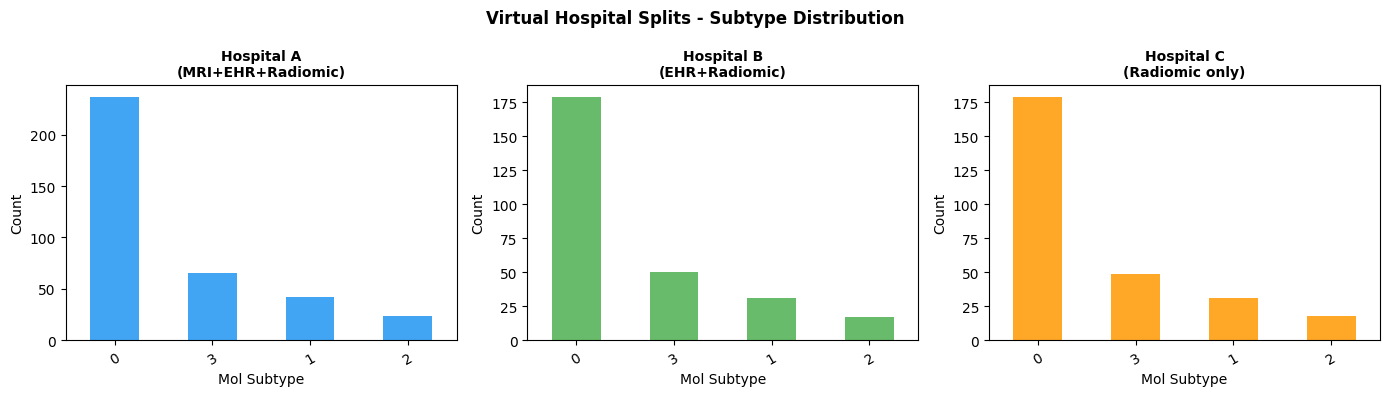

Hospital A: 368 patients | MRI + EHR + Radiomic
Hospital B: 277 patients | EHR + Radiomic (MRI removed)
Hospital C: 277 patients | Radiomic only


In [20]:
processed_patients = [f.stem for f in NPY_DIR.glob('*.npy')]
print(f"Patients with MRI .npy: {len(processed_patients)}")

df_final = df_merged[df_merged[PATIENT_ID_COL].isin(processed_patients)].copy().reset_index(drop=True)
print(f"Final dataset: {len(df_final)} patients")

ehr_final, rad_final, _, _, _ = preprocess_tabular(df_final, ehr_cols, radiomic_cols, fit=True)
labels = df_final['subtype_label'].values

# Split: A=40%, B=30%, C=30%
idx_A, idx_BC = train_test_split(range(len(df_final)), test_size=0.60, stratify=labels, random_state=42)
labels_BC = labels[list(idx_BC)]
idx_Bl, idx_Cl = train_test_split(range(len(idx_BC)), test_size=0.50, stratify=labels_BC, random_state=42)
idx_B = [list(idx_BC)[i] for i in idx_Bl]
idx_C = [list(idx_BC)[i] for i in idx_Cl]

df_A = df_final.iloc[list(idx_A)].copy()
df_B = df_final.iloc[list(idx_B)].copy()
df_C = df_final.iloc[list(idx_C)].copy()

df_A.to_csv(SPLIT_DIR / 'hospital_A.csv', index=False)
df_B.to_csv(SPLIT_DIR / 'hospital_B.csv', index=False)
df_C.to_csv(SPLIT_DIR / 'hospital_C.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df_h, title, color in zip(
    axes, [df_A, df_B, df_C],
    ['Hospital A\n(MRI+EHR+Radiomic)', 'Hospital B\n(EHR+Radiomic)', 'Hospital C\n(Radiomic only)'],
    ['#2196F3', '#4CAF50', '#FF9800']
):
    df_h[SUBTYPE_COL].value_counts().plot(kind='bar', ax=ax, color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Virtual Hospital Splits - Subtype Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'hospital_splits.png', dpi=150)
plt.show()

print(f"Hospital A: {len(df_A)} patients | MRI + EHR + Radiomic")
print(f"Hospital B: {len(df_B)} patients | EHR + Radiomic (MRI removed)")
print(f"Hospital C: {len(df_C)} patients | Radiomic only")


In [21]:
class BreastCancerDataset(Dataset):
    def __init__(self, df, npy_dir, ehr_array, radiomic_array,
                 pid_col, label_col, df_full,
                 has_mri=True, has_ehr=True, has_radiomic=True,
                 transform=None):
        self.df           = df.reset_index(drop=True)
        self.npy_dir      = Path(npy_dir)
        self.ehr          = ehr_array
        self.radiomic     = radiomic_array
        self.pid_col      = pid_col
        self.label_col    = label_col
        self.has_mri      = has_mri
        self.has_ehr      = has_ehr
        self.has_radiomic = has_radiomic
        self.transform    = transform
        self.ehr_dim      = ehr_array.shape[1]
        self.rad_dim      = radiomic_array.shape[1]

        full_ids = df_full[pid_col].tolist()
        self.full_idx = [
            full_ids.index(pid) if pid in full_ids else -1
            for pid in self.df[pid_col].tolist()
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row   = self.df.iloc[i]
        pid   = row[self.pid_col]
        label = int(row[self.label_col])
        fi    = self.full_idx[i]

        if self.has_mri:
            p = self.npy_dir / f"{pid}.npy"
            mri = torch.tensor(np.load(str(p)), dtype=torch.float32) if p.exists() else torch.zeros(3, 224, 224)
            if self.transform:
                mri = self.transform(mri)
        else:
            mri = torch.zeros(3, 224, 224)

        ehr = torch.tensor(self.ehr[fi], dtype=torch.float32) if (self.has_ehr and fi >= 0) else torch.zeros(self.ehr_dim)
        rad = torch.tensor(self.radiomic[fi], dtype=torch.float32) if (self.has_radiomic and fi >= 0) else torch.zeros(self.rad_dim)

        mask = torch.tensor([float(self.has_mri), float(self.has_ehr), float(self.has_radiomic)], dtype=torch.float32)

        return {'mri': mri, 'ehr': ehr, 'radiomic': rad,
                'modality_mask': mask,
                'label': torch.tensor(label, dtype=torch.long),
                'patient_id': pid}


train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

BATCH = 8

ds_A = BreastCancerDataset(df_A, NPY_DIR, ehr_final, rad_final, PATIENT_ID_COL, 'subtype_label', df_final,
                            has_mri=True, has_ehr=True, has_radiomic=True, transform=train_tf)
ds_B = BreastCancerDataset(df_B, NPY_DIR, ehr_final, rad_final, PATIENT_ID_COL, 'subtype_label', df_final,
                            has_mri=False, has_ehr=True, has_radiomic=True, transform=val_tf)
ds_C = BreastCancerDataset(df_C, NPY_DIR, ehr_final, rad_final, PATIENT_ID_COL, 'subtype_label', df_final,
                            has_mri=False, has_ehr=False, has_radiomic=True, transform=val_tf)

loader_A = DataLoader(ds_A, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
loader_B = DataLoader(ds_B, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
loader_C = DataLoader(ds_C, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"Dataset A: {len(ds_A)} samples, {len(loader_A)} batches")
print(f"Dataset B: {len(ds_B)} samples, {len(loader_B)} batches")
print(f"Dataset C: {len(ds_C)} samples, {len(loader_C)} batches")

s = ds_A[0]
print(f"\nSample shapes - MRI:{s['mri'].shape}  EHR:{s['ehr'].shape}  Radiomic:{s['radiomic'].shape}")


Dataset A: 368 samples, 46 batches
Dataset B: 277 samples, 35 batches
Dataset C: 277 samples, 35 batches

Sample shapes - MRI:torch.Size([3, 224, 224])  EHR:torch.Size([50])  Radiomic:torch.Size([529])


In [22]:
def gn(c, max_groups=8):
    g = min(max_groups, c)
    while c % g != 0:
        g -= 1
    return nn.GroupNorm(g, c)


class MRIEncoder(nn.Module):
    def __init__(self, out_dim=256, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=0)
        self.proj = nn.Sequential(
            nn.Linear(self.backbone.num_features, 512), gn(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, out_dim)
        )
        self.out_dim = out_dim

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x)
        return F.normalize(self.proj(feat.detach()), p=2, dim=1)


class RadiomicEncoder(nn.Module):
    def __init__(self, in_dim=529, out_dim=128):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 256), gn(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), gn(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, out_dim), gn(out_dim), nn.ReLU()
        )
        self.out_dim = out_dim

    def forward(self, x):
        return self.enc(x)


class EHREncoder(nn.Module):
    def __init__(self, in_dim=50, out_dim=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 128), gn(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), gn(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, out_dim), gn(out_dim), nn.ReLU()
        )
        self.out_dim = out_dim

    def forward(self, x):
        return self.enc(x)


class LocalModel(nn.Module):
    def __init__(self, n_classes=4, rad_in=529, ehr_in=50):
        super().__init__()
        self.mri_enc = MRIEncoder(out_dim=256)
        self.rad_enc = RadiomicEncoder(in_dim=rad_in, out_dim=128)
        self.ehr_enc = EHREncoder(in_dim=ehr_in, out_dim=64)
        self.fusion = nn.Sequential(
            nn.Linear(256 + 128 + 64, 256), gn(256), nn.ReLU(), nn.Dropout(0.4)
        )
        self.head_subtype = nn.Linear(256, n_classes)
        self.head_pcr = nn.Linear(256, 1)

    def forward(self, mri, ehr, rad, mask, task='subtype'):
        # `mri` is either a raw image (B,3,224,224) -> encode with MRIEncoder,
        # or a pre-computed 256-d embedding (B,256) -> real-cached / FeatureImpNet-imputed,
        # injected directly (skipping MRIEncoder). This lets Hospitals B/C participate in FL
        # using imputed MRI embeddings without ever touching a real MRI pixel (see Sec. 13-14).
        if mri.dim() == 4:
            f_mri = self.mri_enc(mri) * mask[:, 0:1]
        else:
            f_mri = mri * mask[:, 0:1]
        f_rad = self.rad_enc(rad) * mask[:, 2:3]
        f_ehr = self.ehr_enc(ehr) * mask[:, 1:2]
        fused = self.fusion(torch.cat([f_mri, f_rad, f_ehr], dim=1))
        if task == 'subtype':
            return self.head_subtype(fused), fused
        return self.head_pcr(fused), fused


N_CLASSES = len(le.classes_)
model = LocalModel(n_classes=N_CLASSES, rad_in=rad_final.shape[1], ehr_in=ehr_final.shape[1]).to(device)

total = sum(p.numel() for p in model.parameters())
print(f"Model ready | Parameters: {total:,}")
print(f"   Classes: {list(le.classes_)}")

with torch.no_grad():
    dummy_out, _ = model(
        torch.zeros(4, 3, 224, 224).to(device),
        torch.zeros(4, ehr_final.shape[1]).to(device),
        torch.zeros(4, rad_final.shape[1]).to(device),
        torch.ones(4, 3).to(device)
    )
print(f"   Forward pass output: {dummy_out.shape}")


08/29/2026 17:57:59:WARNING:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model ready | Parameters: 5,118,081
   Classes: ['0', '1', '2', '3']
   Forward pass output: torch.Size([4, 4])


In [23]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses, preds_all, labels_all = [], [], []
    for batch in tqdm(loader, desc='Train', leave=False):
        mri  = batch['mri'].to(device)
        ehr  = batch['ehr'].to(device)
        rad  = batch['radiomic'].to(device)
        mask = batch['modality_mask'].to(device)
        lbl  = batch['label'].to(device)
        optimizer.zero_grad()
        logits, _ = model(mri, ehr, rad, mask)
        loss = criterion(logits, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(lbl.cpu().numpy())
    acc = np.mean(np.array(preds_all) == np.array(labels_all))
    return np.mean(losses), acc


@torch.no_grad()
def eval_epoch(model, loader, criterion, device, n_classes):
    model.eval()
    losses, preds_all, labels_all, probs_all = [], [], [], []
    for batch in tqdm(loader, desc='Val  ', leave=False):
        mri  = batch['mri'].to(device)
        ehr  = batch['ehr'].to(device)
        rad  = batch['radiomic'].to(device)
        mask = batch['modality_mask'].to(device)
        lbl  = batch['label'].to(device)
        logits, _ = model(mri, ehr, rad, mask)
        loss = criterion(logits, lbl)
        losses.append(loss.item())
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(lbl.cpu().numpy())
        probs_all.extend(probs)
    acc = np.mean(np.array(preds_all) == np.array(labels_all))
    try:
        auc = roc_auc_score(labels_all, np.array(probs_all), multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0
    return np.mean(losses), acc, auc, preds_all, labels_all

print("Training functions ready!")


Training functions ready!


In [24]:
# Train from Hospital A
tr_idx, vl_idx = train_test_split(
    range(len(ds_A)), test_size=0.2, stratify=df_A['subtype_label'].values, random_state=42
)

N_CLASSES = df_A['subtype_label'].nunique()
print("N_CLASSES =", N_CLASSES)
train_labels = df_A.iloc[list(tr_idx)]['subtype_label'].values
w = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=train_labels)

# --- FIX 1: WeightedRandomSampler on top of class-weighted loss --------------
# compute_class_weight already reweights the LOSS, but with only ~295 training
# patients and a 65% / 18% / 11% / 6% class split, the minority classes are
# still barely *seen* per epoch. A WeightedRandomSampler additionally
# oversamples minority-class patients when building each batch, so the model
# gets many more looks at Luminal-B / HER2 / Triple-Neg examples per epoch.
sample_weights = w[train_labels]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True,
)
tr_loader = DataLoader(Subset(ds_A, tr_idx), batch_size=BATCH, sampler=sampler, num_workers=0)
vl_loader = DataLoader(Subset(ds_A, vl_idx), batch_size=BATCH, shuffle=False,  num_workers=0)

# --- FIX 2: small label smoothing -------------------------------------------
# Softens the one-hot targets slightly (0.05) so the model is less overconfident
# on the majority class, which tends to help both accuracy and AUC on a very
# imbalanced, small validation set.
criterion = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device),
                                 label_smoothing=0.05)

# EfficientNet backbone freeze করো — ছোট dataset-এ পুরো backbone fine-tune করলে overfit করে
for p in model.mri_enc.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-5
)

# --- FIX 3: gentler / adaptive LR schedule ----------------------------------
# StepLR(step_size=5, gamma=0.5) was HALVING the LR every 5 epochs, so by epoch
# ~25 the LR was already ~3e-6 (essentially zero) even though N_EPOCHS=100 and
# PATIENCE=15 — the model had effectively stopped learning for the last 75
# epochs. ReduceLROnPlateau only cuts the LR when validation AUC actually
# stalls, so the model keeps learning for as long as it is still improving.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

print(f"Train: {len(tr_idx)} | Val: {len(vl_idx)}")
print(f"Class weights: {w.round(3)}")


N_CLASSES = 4
Train: 294 | Val: 74
Class weights: [0.389 2.162 3.868 1.413]


In [25]:
N_EPOCHS = 100
history  = {'tr_loss': [], 'vl_loss': [], 'tr_acc': [], 'vl_acc': [], 'vl_auc': []}
best_auc = 0.0
best_acc = 0.0          # FIX: track best VAL ACCURACY too, not just AUC
CKPT       = CHECKPOINT_DIR / 'best_hospitalA_auc.pth'   # best-by-AUC (as before)
CKPT_ACC   = CHECKPOINT_DIR / 'best_hospitalA_acc.pth'   # NEW: best-by-ACCURACY
CKPT_BOTH  = CHECKPOINT_DIR / 'best_hospitalA_both0.8.pth'  # NEW: saved only once BOTH acc & AUC >= 0.80

PATIENCE = 50   # a bit more patient now that the LR schedule is adaptive, not fixed-decay
epochs_no_improve = 0

print(f"Training - Hospital A (Centralized Upper Bound)")
print(f"   Epochs: {N_EPOCHS} | Batch: {BATCH} | Device: {device}")
print()

for ep in range(1, N_EPOCHS + 1):
    tl, ta = train_epoch(model, tr_loader, optimizer, criterion, device)
    vl, va, vauc, vp, vlbl = eval_epoch(model, vl_loader, criterion, device, N_CLASSES)
    scheduler.step(vauc)   # FIX: ReduceLROnPlateau needs the metric it's watching

    history['tr_loss'].append(tl); history['vl_loss'].append(vl)
    history['tr_acc'].append(ta);  history['vl_acc'].append(va)
    history['vl_auc'].append(vauc)

    tag = ''
    # --- save best-by-AUC checkpoint (unchanged behaviour) ---
    if vauc > best_auc:
        best_auc = vauc
        torch.save(model.state_dict(), CKPT)
        tag += '  <- best AUC'
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # --- FIX: ALSO save best-by-ACCURACY checkpoint (this is what you asked for) ---
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), CKPT_ACC)
        tag += '  <- best ACC'

    # --- save a checkpoint the moment BOTH targets (acc >= 0.8 and auc >= 0.8) are met ---
    if va >= 0.80 and vauc >= 0.80:
        torch.save(model.state_dict(), CKPT_BOTH)
        tag += '  *** ACC & AUC >= 0.80 ***'

    print(f"Ep [{ep:3d}/{N_EPOCHS}]  Train Loss:{tl:.4f} Acc:{ta:.3f}  |  "
          f"Val Loss:{vl:.4f} Acc:{va:.3f} AUC:{vauc:.3f}  LR:{optimizer.param_groups[0]['lr']:.2e}{tag}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping — {PATIENCE} epochs no AUC improvement. "
              f"Best AUC: {best_auc:.4f} | Best Acc: {best_acc:.4f}")
        N_EPOCHS = ep   # পরের cell (training curve plot)-এর জন্য actual epoch সংখ্যা রাখা
        break

print(f"\nBest Val AUC: {best_auc:.4f}  -> {CKPT}")
print(f"Best Val Acc: {best_acc:.4f}  -> {CKPT_ACC}")
if CKPT_BOTH.exists():
    print(f"Both >= 0.80 checkpoint saved -> {CKPT_BOTH}")
else:
    print("Both->=0.80 checkpoint NOT yet reached — see the improvement notes for what to try next.")


Training - Hospital A (Centralized Upper Bound)
   Epochs: 100 | Batch: 8 | Device: cuda



Train:   0%|          | 0/37 [00:00<?, ?it/s]

Val  :   0%|          | 0/10 [00:00<?, ?it/s]

Ep [  1/100]  Train Loss:1.2233 Acc:0.269  |  Val Loss:1.9104 Acc:0.068 AUC:0.501  LR:1.00e-04  <- best AUC  <- best ACC


Train:   0%|          | 0/37 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/10 [00:00<?, ?it/s]

Ep [ 98/100]  Train Loss:0.2092 Acc:0.993  |  Val Loss:0.8408 Acc:0.892 AUC:0.938  LR:1.00e-06  *** ACC & AUC >= 0.80 ***


Train:   0%|          | 0/37 [00:00<?, ?it/s]

Val  :   0%|          | 0/10 [00:00<?, ?it/s]

Ep [ 99/100]  Train Loss:0.1937 Acc:1.000  |  Val Loss:0.8593 Acc:0.878 AUC:0.925  LR:1.00e-06  *** ACC & AUC >= 0.80 ***

Early stopping — 50 epochs no AUC improvement. Best AUC: 0.9542 | Best Acc: 0.9054

Best Val AUC: 0.9542  -> /kaggle/working/duke_breast_cancer/checkpoints/best_hospitalA_auc.pth
Best Val Acc: 0.9054  -> /kaggle/working/duke_breast_cancer/checkpoints/best_hospitalA_acc.pth
Both >= 0.80 checkpoint saved -> /kaggle/working/duke_breast_cancer/checkpoints/best_hospitalA_both0.8.pth


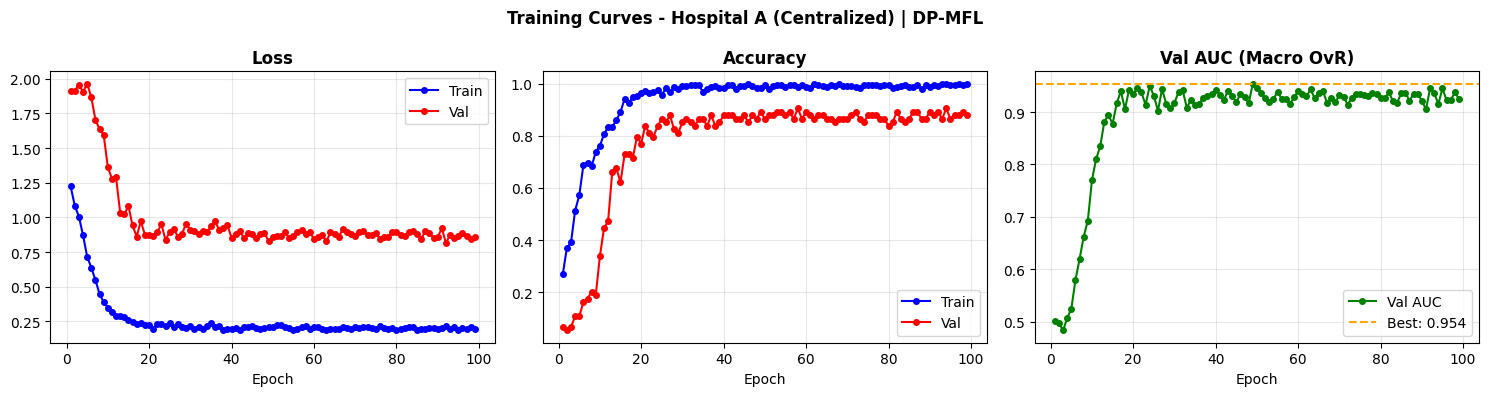

Saved!


In [26]:
# Training curves
eps = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(eps, history['tr_loss'], 'b-o', label='Train', ms=4)
axes[0].plot(eps, history['vl_loss'], 'r-o', label='Val', ms=4)
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history['tr_acc'], 'b-o', label='Train', ms=4)
axes[1].plot(eps, history['vl_acc'], 'r-o', label='Val', ms=4)
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(eps, history['vl_auc'], 'g-o', label='Val AUC', ms=4)
axes[2].axhline(best_auc, color='orange', ls='--', label=f'Best: {best_auc:.3f}')
axes[2].set_title('Val AUC (Macro OvR)', fontweight='bold'); axes[2].legend(); axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Epoch')
plt.suptitle('Training Curves - Hospital A (Centralized) | DP-MFL', fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'training_curves.png', dpi=150)
plt.show()
print("Saved!")


In [27]:
# Final classification report
model.load_state_dict(torch.load(CKPT))
_, _, _, final_preds, final_labels = eval_epoch(model, vl_loader, criterion, device, N_CLASSES)
print("=== Classification Report - Hospital A Validation ===")
print(classification_report(final_labels, final_preds, target_names=le.classes_))


Val  :   0%|          | 0/10 [00:00<?, ?it/s]

=== Classification Report - Hospital A Validation ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        48
           1       0.71      0.62      0.67         8
           2       0.50      0.40      0.44         5
           3       0.86      0.92      0.89        13

    accuracy                           0.89        74
   macro avg       0.76      0.73      0.74        74
weighted avg       0.88      0.89      0.89        74



In [28]:
# Extract the MRI embedding bank from Hospital A using the trained MRI encoder
model.eval()

@torch.no_grad()
def extract_mri_embeddings(model, dataset, device, batch_size=16):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embs = []
    for batch in tqdm(loader, desc='Extracting MRI embeddings'):
        mri = batch['mri'].to(device)
        emb = model.mri_enc(mri)
        embs.append(emb.cpu().numpy())
    return np.concatenate(embs, axis=0)

mri_embeddings_A = extract_mri_embeddings(model, ds_A, device)
print(f"Hospital A MRI embedding bank: {mri_embeddings_A.shape}")

radiomic_A = np.stack([ds_A[i]['radiomic'].numpy() for i in range(len(ds_A))], axis=0)
print(f"Hospital A radiomic bank     : {radiomic_A.shape}")

np.save(BASE_DIR / 'mri_embeddings_A.npy', mri_embeddings_A)
np.save(BASE_DIR / 'radiomic_A.npy', radiomic_A)


Extracting MRI embeddings:   0%|          | 0/23 [00:00<?, ?it/s]

Hospital A MRI embedding bank: (368, 256)
Hospital A radiomic bank     : (368, 529)


In [29]:
# Split Hospital A into a fixed reference BANK and a QUERY set with known ground truth.
# The imputation network is trained/validated ONLY on the query set attending over the bank,
# so there is no self-leakage (a patient never attends over her own MRI embedding).

A_idx = np.arange(len(ds_A))
bank_idx, query_idx = train_test_split(A_idx, test_size=0.30, random_state=42)

bank_rad  = torch.tensor(radiomic_A[bank_idx],  dtype=torch.float32)        # (N_bank, 529)
bank_mri  = torch.tensor(mri_embeddings_A[bank_idx], dtype=torch.float32)   # (N_bank, 256)
query_rad = torch.tensor(radiomic_A[query_idx], dtype=torch.float32)        # (N_query, 529)
query_mri = torch.tensor(mri_embeddings_A[query_idx], dtype=torch.float32)  # (N_query, 256) ground truth

print(f"Reference bank : {bank_rad.shape[0]} patients")
print(f"Query (train)  : {query_rad.shape[0]} patients")


Reference bank : 257 patients
Query (train)  : 111 patients


In [30]:
class FeatureImpNet(nn.Module):
    def __init__(self, rad_dim=529, mri_dim=256, d_model=256, n_heads=4, dropout=0.2):
        super().__init__()
        self.query_proj = nn.Sequential(
            nn.Linear(rad_dim, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout)
        )
        self.key_proj = nn.Sequential(
            nn.Linear(rad_dim, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout)
        )
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads,
                                           kdim=d_model, vdim=mri_dim,
                                           dropout=dropout, batch_first=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, mri_dim), nn.LayerNorm(mri_dim)
        )
        self.mri_dim = mri_dim

    def forward(self, query_rad, bank_rad, bank_mri):
        B = query_rad.size(0)
        q = self.query_proj(query_rad).unsqueeze(1)                     # (B,1,d_model)
        k = self.key_proj(bank_rad).unsqueeze(0).expand(B, -1, -1)      # (B,N_bank,d_model)
        v = bank_mri.unsqueeze(0).expand(B, -1, -1)                     # (B,N_bank,mri_dim)
        attn_out, attn_w = self.attn(q, k, v, need_weights=True)        # (B,1,d_model)
        imputed = self.out_proj(attn_out.squeeze(1))                    # (B,mri_dim)
        return F.normalize(imputed, p=2, dim=1), attn_w.squeeze(1)

feature_imp_net = FeatureImpNet(rad_dim=radiomic_A.shape[1], mri_dim=256).to(device)
total_params = sum(p.numel() for p in feature_imp_net.parameters())
print(f"FeatureImpNet ready | Parameters: {total_params:,}")


FeatureImpNet ready | Parameters: 601,856


In [31]:
imp_optimizer = torch.optim.Adam(feature_imp_net.parameters(), lr=1e-3, weight_decay=1e-5)
imp_scheduler = torch.optim.lr_scheduler.StepLR(imp_optimizer, step_size=20, gamma=0.5)

bank_rad_dev, bank_mri_dev   = bank_rad.to(device), bank_mri.to(device)
query_rad_dev, query_mri_dev = query_rad.to(device), query_mri.to(device)

IMP_EPOCHS = 350
imp_history = {'loss': [], 'cosine_sim': []}
best_cos = -1.0
IMP_CKPT = CHECKPOINT_DIR / 'feature_imp_net.pth'

def imputation_loss(pred, target):
    mse = F.mse_loss(pred, target)
    cos = 1 - F.cosine_similarity(pred, target, dim=1).mean()
    return mse + 0.5 * cos

print("Training FeatureImpNet (cross-attention MRI imputation)")
for ep in range(1, IMP_EPOCHS + 1):
    feature_imp_net.train()
    imp_optimizer.zero_grad()
    pred, _ = feature_imp_net(query_rad_dev, bank_rad_dev, bank_mri_dev)
    loss = imputation_loss(pred, query_mri_dev)
    loss.backward()
    nn.utils.clip_grad_norm_(feature_imp_net.parameters(), 1.0)
    imp_optimizer.step()
    imp_scheduler.step()

    with torch.no_grad():
        cos_sim = F.cosine_similarity(pred, query_mri_dev, dim=1).mean().item()
    imp_history['loss'].append(loss.item())
    imp_history['cosine_sim'].append(cos_sim)

    if cos_sim > best_cos:
        best_cos = cos_sim
        torch.save(feature_imp_net.state_dict(), IMP_CKPT)
        
    else:
        tag = ''

    if ep % 5 == 0 or ep == 1:
        print(f"Ep [{ep:3d}/{IMP_EPOCHS}]  Loss:{loss.item():.4f}  CosineSim:{cos_sim:.4f}{tag}")

print(f"\nBest cosine similarity (imputed vs real MRI embedding): {best_cos:.4f}")
feature_imp_net.load_state_dict(torch.load(IMP_CKPT))


Training FeatureImpNet (cross-attention MRI imputation)
Ep [  1/350]  Loss:0.5288  CosineSim:-0.0413  *** ACC & AUC >= 0.80 ***
Ep [  5/350]  Loss:0.3178  CosineSim:0.3742  *** ACC & AUC >= 0.80 ***
Ep [ 10/350]  Loss:0.2552  CosineSim:0.4974  *** ACC & AUC >= 0.80 ***
Ep [ 15/350]  Loss:0.2517  CosineSim:0.5043  *** ACC & AUC >= 0.80 ***
Ep [ 20/350]  Loss:0.2485  CosineSim:0.5107  *** ACC & AUC >= 0.80 ***
Ep [ 25/350]  Loss:0.2472  CosineSim:0.5132  *** ACC & AUC >= 0.80 ***
Ep [ 30/350]  Loss:0.2463  CosineSim:0.5150  *** ACC & AUC >= 0.80 ***
Ep [ 35/350]  Loss:0.2457  CosineSim:0.5162  *** ACC & AUC >= 0.80 ***
Ep [ 40/350]  Loss:0.2448  CosineSim:0.5180  *** ACC & AUC >= 0.80 ***
Ep [ 45/350]  Loss:0.2436  CosineSim:0.5202  *** ACC & AUC >= 0.80 ***
Ep [ 50/350]  Loss:0.2424  CosineSim:0.5226
Ep [ 55/350]  Loss:0.2396  CosineSim:0.5281
Ep [ 60/350]  Loss:0.2365  CosineSim:0.5344
Ep [ 65/350]  Loss:0.2346  CosineSim:0.5380
Ep [ 70/350]  Loss:0.2313  CosineSim:0.5445
Ep [ 75/350] 

<All keys matched successfully>

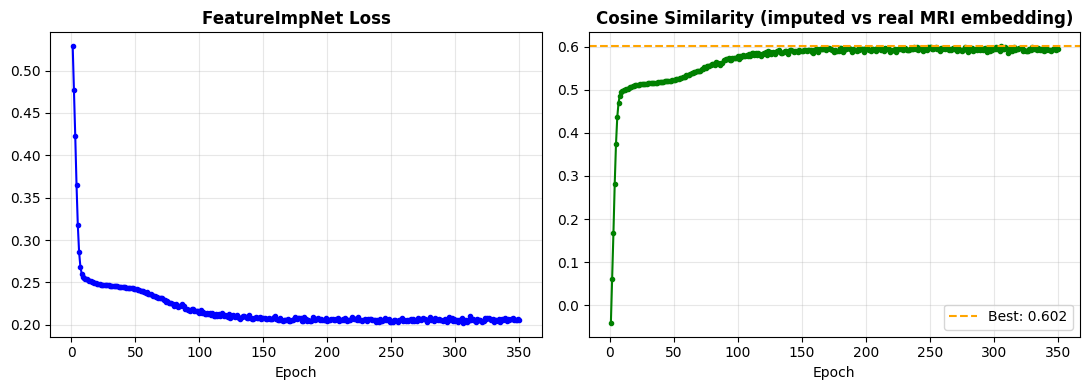

In [32]:
# Imputation training curves
eps_imp = range(1, IMP_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(eps_imp, imp_history['loss'], 'b-o', ms=3)
axes[0].set_title('FeatureImpNet Loss', fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(eps_imp, imp_history['cosine_sim'], 'g-o', ms=3)
axes[1].axhline(best_cos, color='orange', ls='--', label=f'Best: {best_cos:.3f}')
axes[1].set_title('Cosine Similarity (imputed vs real MRI embedding)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / 'feature_imp_net_curves.png', dpi=150)
plt.show()


Imputed MRI embeddings -> Hospital B: (277, 256), Hospital C: (277, 256)
Hospital B mean attention entropy (lower = more peaked on a few similar patients): 2.345
Hospital C mean attention entropy: 2.400


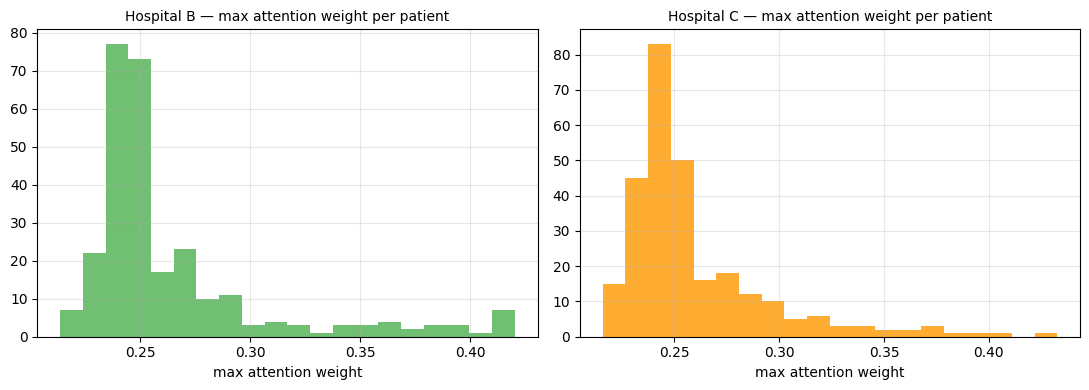

In [33]:
feature_imp_net.load_state_dict(torch.load(IMP_CKPT))
feature_imp_net.eval()

full_bank_rad = torch.tensor(radiomic_A, dtype=torch.float32).to(device)
full_bank_mri = torch.tensor(mri_embeddings_A, dtype=torch.float32).to(device)

def impute_mri_for_hospital(df_h, ds_h):
    """Order-matched radiomic features for df_h, imputed via FeatureImpNet over the full A bank."""
    rad_h = rad_final[ds_h.full_idx]                       # (N_h, 529), row order == df_h
    rad_h_t = torch.tensor(rad_h, dtype=torch.float32).to(device)
    with torch.no_grad():
        imputed, attn_w = feature_imp_net(rad_h_t, full_bank_rad, full_bank_mri)
    return imputed.cpu().numpy(), attn_w.cpu().numpy()

imputed_mri_B, attn_B = impute_mri_for_hospital(df_B, ds_B)
imputed_mri_C, attn_C = impute_mri_for_hospital(df_C, ds_C)

np.save(BASE_DIR / 'imputed_mri_B.npy', imputed_mri_B)
np.save(BASE_DIR / 'imputed_mri_C.npy', imputed_mri_C)

print(f"Imputed MRI embeddings -> Hospital B: {imputed_mri_B.shape}, Hospital C: {imputed_mri_C.shape}")
print(f"Hospital B mean attention entropy (lower = more peaked on a few similar patients): "
      f"{(-(attn_B * np.log(attn_B + 1e-9)).sum(1)).mean():.3f}")
print(f"Hospital C mean attention entropy: "
      f"{(-(attn_C * np.log(attn_C + 1e-9)).sum(1)).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(attn_B.max(axis=1), bins=20, color='#4CAF50', alpha=0.8)
axes[0].set_title('Hospital B — max attention weight per patient', fontsize=10)
axes[0].set_xlabel('max attention weight'); axes[0].grid(alpha=0.3)
axes[1].hist(attn_C.max(axis=1), bins=20, color='#FF9800', alpha=0.8)
axes[1].set_title('Hospital C — max attention weight per patient', fontsize=10)
axes[1].set_xlabel('max attention weight'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / 'imputed_attention_weights.png', dpi=120)
plt.show()


In [34]:
from torch.utils.data import ConcatDataset
class FederatedDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        df,
        ehr_data,
        radiomic_data,
        full_idx,
        patient_id_col,
        label_col,
        mri_mode='real',
        npy_dir=None,
        imputed_mri=None,
        has_ehr=True,
        has_radiomic=True,
        transform=None
    ):
        self.df = df.reset_index(drop=True).copy()
        self.ehr_data = ehr_data
        self.radiomic_data = radiomic_data
        self.full_idx = np.asarray(full_idx)
        self.patient_id_col = patient_id_col
        self.label_col = label_col

        self.mri_mode = mri_mode
        self.npy_dir = npy_dir
        self.imputed_mri = imputed_mri

        self.has_ehr = has_ehr
        self.has_radiomic = has_radiomic
        self.transform = transform

        # Make sure the number of rows matches
        assert len(self.df) == len(self.full_idx), (
            f"df length ({len(self.df)}) != full_idx length ({len(self.full_idx)})"
        )

    def __len__(self):
        return len(self.df)

    def _get_ehr(self, idx):
        if not self.has_ehr:
            return torch.zeros(
                self.ehr_data.shape[1],
                dtype=torch.float32
            )

        row_idx = self.full_idx[idx]

        if isinstance(self.ehr_data, pd.DataFrame):
            x = self.ehr_data.iloc[row_idx].values
        else:
            x = self.ehr_data[row_idx]

        x = np.asarray(x, dtype=np.float32)

        return torch.tensor(x, dtype=torch.float32)

    def _get_radiomic(self, idx):
        if not self.has_radiomic:
            return torch.zeros(
                self.radiomic_data.shape[1],
                dtype=torch.float32
            )

        row_idx = self.full_idx[idx]

        if isinstance(self.radiomic_data, pd.DataFrame):
            x = self.radiomic_data.iloc[row_idx].values
        else:
            x = self.radiomic_data[row_idx]

        x = np.asarray(x, dtype=np.float32)

        return torch.tensor(x, dtype=torch.float32)

    def _get_mri(self, idx):
        # --------------------------------------------------
        # Real MRI
        # --------------------------------------------------
        if self.mri_mode == 'real':

            if self.npy_dir is None:
                raise ValueError(
                    "npy_dir is required when mri_mode='real'"
                )

            patient_id = self.df.iloc[idx][self.patient_id_col]

            npy_path = os.path.join(
                str(self.npy_dir),
                f"{patient_id}.npy"
            )

            if not os.path.exists(npy_path):
                raise FileNotFoundError(
                    f"MRI file not found: {npy_path}"
                )

            mri = np.load(npy_path)

            mri = np.asarray(
                mri,
                dtype=np.float32
            )

            mri = torch.tensor(
                mri,
                dtype=torch.float32
            )

            # Expected by model:
            # (C, H, W)
            if mri.ndim == 2:
                mri = mri.unsqueeze(0)

            if self.transform is not None:
                mri = self.transform(mri)

            return mri

        # --------------------------------------------------
        # Imputed MRI embedding
        # --------------------------------------------------
        elif self.mri_mode == 'imputed':

            if self.imputed_mri is None:
                raise ValueError(
                    "imputed_mri is required when mri_mode='imputed'"
                )

            mri = self.imputed_mri[idx]

            return torch.tensor(
                np.asarray(mri, dtype=np.float32),
                dtype=torch.float32
            )

        # --------------------------------------------------
        # Zero-filled MRI embedding
        # --------------------------------------------------
        elif self.mri_mode == 'zero':

            # B/C use imputed MRI embeddings of size 256,
            # therefore zero-fill must also have size 256.
            return torch.zeros(
                256,
                dtype=torch.float32
            )

        else:
            raise ValueError(
                f"Unknown mri_mode: {self.mri_mode}"
            )

    def __getitem__(self, idx):

        mri = self._get_mri(idx)
        ehr = self._get_ehr(idx)
        radiomic = self._get_radiomic(idx)

        label = self.df.iloc[idx][self.label_col]

        label = torch.tensor(
            int(label),
            dtype=torch.long
        )

        # modality mask:
        # [MRI, EHR, Radiomic]
        #
        # 1 = available
        # 0 = missing
        if self.mri_mode in ['real', 'imputed']:
            mri_mask = 1.0
        else:
            mri_mask = 0.0

        ehr_mask = 1.0 if self.has_ehr else 0.0
        radiomic_mask = 1.0 if self.has_radiomic else 0.0

        modality_mask = torch.tensor(
            [mri_mask, ehr_mask, radiomic_mask],
            dtype=torch.float32
        )

        return {
            'mri': mri,
            'ehr': ehr,
            'radiomic': radiomic,
            'modality_mask': modality_mask,
            'label': label
        }


print("FederatedDataset ready.")

FederatedDataset ready.


In [35]:
def build_hospital_loaders(use_imputation=True, batch_size=BATCH):
    ds_A_fl = FederatedDataset(
        df_A, ehr_final, rad_final, ds_A.full_idx, PATIENT_ID_COL,
        'subtype_label',
        mri_mode='real',
        npy_dir=NPY_DIR,
        has_ehr=True,
        has_radiomic=True,
        transform=train_tf
    )

    mode_bc = 'imputed' if use_imputation else 'zero'

    ds_B_fl = FederatedDataset(
        df_B, ehr_final, rad_final, ds_B.full_idx, PATIENT_ID_COL,
        'subtype_label',
        mri_mode=mode_bc,
        imputed_mri=imputed_mri_B,
        has_ehr=True,
        has_radiomic=True,
        transform=val_tf
    )

    ds_C_fl = FederatedDataset(
        df_C, ehr_final, rad_final, ds_C.full_idx, PATIENT_ID_COL,
        'subtype_label',
        mri_mode=mode_bc,
        imputed_mri=imputed_mri_C,
        has_ehr=False,
        has_radiomic=True,
        transform=val_tf
    )

    trA, vlA = train_test_split(
        range(len(ds_A_fl)),
        test_size=0.2,
        stratify=df_A['subtype_label'].values,
        random_state=42
    )

    trB, vlB = train_test_split(
        range(len(ds_B_fl)),
        test_size=0.2,
        stratify=df_B['subtype_label'].values,
        random_state=42
    )

    trC, vlC = train_test_split(
        range(len(ds_C_fl)),
        test_size=0.2,
        stratify=df_C['subtype_label'].values,
        random_state=42
    )

    train_loaders = {
        'A': DataLoader(
            Subset(ds_A_fl, trA),
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        ),
        'B': DataLoader(
            Subset(ds_B_fl, trB),
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        ),
        'C': DataLoader(
            Subset(ds_C_fl, trC),
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        )
    }

    val_loaders = {
        'A': DataLoader(
            Subset(ds_A_fl, vlA),
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        ),
        'B': DataLoader(
            Subset(ds_B_fl, vlB),
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        ),
        'C': DataLoader(
            Subset(ds_C_fl, vlC),
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )
    }

    return train_loaders, val_loaders

In [36]:
@torch.no_grad()
def eval_loader(model, loader, criterion, n_classes):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for batch in loader:

        mri = batch["mri"].to(device)
        ehr = batch["ehr"].to(device)
        rad = batch["radiomic"].to(device)
        mask = batch["modality_mask"].to(device)
        labels = batch["label"].to(device)

        logits, _ = model(
            mri,
            ehr,
            rad,
            mask
        )

        loss = criterion(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        probabilities = F.softmax(
            logits,
            dim=1
        )

        predictions = logits.argmax(
            dim=1
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    # Convert to numpy
    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)
    all_probs_np = np.array(all_probs)

    # Loss
    avg_loss = (
        total_loss / total_samples
        if total_samples > 0
        else 0.0
    )

    # Accuracy
    if total_samples > 0:
        accuracy = float(
            np.mean(
                all_preds_np == all_labels_np
            )
        )
    else:
        accuracy = 0.0

    # AUC
    try:
        auc = roc_auc_score(
            all_labels_np,
            all_probs_np,
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        auc = 0.0

    # F1
    try:
        f1 = f1_score(
            all_labels_np,
            all_preds_np,
            average="macro"
        )
    except Exception:
        f1 = 0.0

    return (
        float(avg_loss),
        float(accuracy),
        float(auc),
        float(f1),
        all_preds,
        all_labels
    )


print("✓ eval_loader ready")

✓ eval_loader ready


In [37]:
# ============================================================
# FEDERATED LEARNING EXPERIMENT
# ============================================================

# --- PyTorch 2.6+ / Opacus compatibility fix (v2 -- patches torch.load directly) ---
# The previous attempt patched opacus.utils.module_utils.clone_module, but
# opacus/validators/module_validator.py imports clone_module via
# `from opacus.utils.module_utils import clone_module`, which creates its own
# independent reference -- patching the original module doesn't touch that copy.
# Patching torch.load() itself works everywhere, since every caller does
# torch.load(...) (attribute lookup at call time), not `from torch import load`.
_original_torch_load = torch.load

def _patched_torch_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _original_torch_load(*args, **kwargs)

torch.load = _patched_torch_load
print("✓ Patched torch.load() default weights_only=False (PyTorch 2.6+ / Opacus fix).")
import copy
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import flwr as fl

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator

from sklearn.metrics import (
    roc_auc_score,
    f1_score
)


# ============================================================
# BATCH SIZE
# ============================================================

BATCH = 16

# ------------------------------------------------------------
# FIX: which centralized checkpoint to warm-start the FL global
# model from. Prefers the best-BY-ACCURACY checkpoint saved in
# the Hospital-A cell above; falls back to the best-by-AUC one,
# then to no warm start at all if neither exists yet.
# ------------------------------------------------------------
if 'CKPT_ACC' in dir() and CKPT_ACC.exists():
    CENTRALIZED_CKPT_PATH = CKPT_ACC
elif 'CKPT' in dir() and CKPT.exists():
    CENTRALIZED_CKPT_PATH = CKPT
else:
    CENTRALIZED_CKPT_PATH = None
    print("⚠ No centralized checkpoint found yet — run the Hospital-A training "
          "cell first if you want the FL experiments to warm-start from it.")


# ============================================================
# 1. MODEL PARAMETER HELPERS
# ============================================================

def get_params(model):
    return [
        v.detach().cpu().numpy()
        for v in model.state_dict().values()
    ]


def set_params(model, params):

    keys = list(model.state_dict().keys())

    sd = OrderedDict()

    for k, v in zip(keys, params):
        sd[k] = torch.tensor(
            v,
            device=device
        )

    model.load_state_dict(
        sd,
        strict=True
    )


# ============================================================
# 2a. SHARED FROZEN MRI ENCODER (precompute embeddings outside the model)
# ============================================================

_shared_mri_encoder = MRIEncoder(out_dim=256).to(device)
if CENTRALIZED_CKPT_PATH is not None and CENTRALIZED_CKPT_PATH.exists():
    ckpt_state = torch.load(CENTRALIZED_CKPT_PATH, map_location=device)
    mri_enc_state = {k[len("mri_enc."):]: v for k, v in ckpt_state.items() if k.startswith("mri_enc.")}
    _shared_mri_encoder.load_state_dict(mri_enc_state, strict=False)
_shared_mri_encoder.eval()
for p in _shared_mri_encoder.parameters():
    p.requires_grad = False

def precompute_mri(mri_batch):
    """Raw MRI (B,3,224,224) hole frozen backbone diye 256-d embedding banay.
    Already-embedding (B,256) hole as-is pass through."""
    if mri_batch.dim() == 4:
        with torch.no_grad():
            return _shared_mri_encoder(mri_batch)
    return mri_batch

# ============================================================
# 2. DP-SAFE MODEL CREATION
# ============================================================

def make_model(
    n_classes,
    rad_in,
    ehr_in,
    dp_safe=False
):

    m = LocalModel(
        n_classes=n_classes,
        rad_in=rad_in,
        ehr_in=ehr_in
    )

    for p in m.mri_enc.backbone.parameters():
        p.requires_grad = False

   # FL model-e backbone rakhar dorkar nai -- always frozen, always
    # externally precomputed (dekhun precompute_mri() niche). Opacus-er
    # module-tree-e BatchNorm2d thakle DP kokhono attach hobe na, tai
    # backbone-ke ekdom bad diye Identity boshiye deya hocche. GroupNorm-e
    # convert kora trainable layer gulo (proj/rad_enc/ehr_enc/fusion,
    # cell 21 change) already DP-safe, tai ModuleValidator.fix()/validate()
    # ar dorkar nai.
    for p in m.mri_enc.proj.parameters():
        p.requires_grad = False

    m.mri_enc.backbone = nn.Identity()

    return m.to(device)
    
   

# ============================================================
# 3. EVALUATION FUNCTION
# ============================================================

@torch.no_grad()
def eval_loader(
    model,
    loader,
    criterion,
    n_classes
):

    model.eval()

    losses = []
    preds = []
    labels = []
    probs = []

    for batch in loader:

        mri = batch["mri"].to(device)
        mri = precompute_mri(mri) 
        ehr = batch["ehr"].to(device)
        rad = batch["radiomic"].to(device)
        mask = batch["modality_mask"].to(device)
        lbl = batch["label"].to(device)

        logits, _ = model(
            mri,
            ehr,
            rad,
            mask
        )

        loss = criterion(
            logits,
            lbl
        )

        losses.append(
            float(loss.item())
        )

        batch_probs = F.softmax(
            logits,
            dim=1
        )

        probs.extend(
            batch_probs.cpu().numpy()
        )

        preds.extend(
            logits.argmax(dim=1)
            .cpu()
            .numpy()
        )

        labels.extend(
            lbl.cpu()
            .numpy()
        )

    # ========================================================
    # CONVERT TO NUMPY
    # ========================================================

    labels_np = np.array(
        labels
    )

    preds_np = np.array(
        preds
    )

    probs_np = np.array(
        probs
    )

    # ========================================================
    # ACCURACY
    # ========================================================

    if len(labels_np) > 0:

        acc = float(
            np.mean(
                preds_np == labels_np
            )
        )

    else:

        acc = 0.0

    # ========================================================
    # AUC
    # ========================================================

    try:

        if (
            len(labels_np) > 0
            and len(np.unique(labels_np)) > 1
            and probs_np.ndim == 2
            and probs_np.shape[1] == n_classes
        ):

            auc = roc_auc_score(
                labels_np,
                probs_np,
                multi_class="ovr",
                average="macro"
            )

        else:

            auc = 0.0

    except Exception:

        auc = 0.0

    # ========================================================
    # F1
    # ========================================================

    try:

        if len(labels_np) > 0:

            f1 = f1_score(
                labels_np,
                preds_np,
                average="macro",
                zero_division=0
            )

        else:

            f1 = 0.0

    except Exception:

        f1 = 0.0

    # ========================================================
    # MEAN LOSS
    # ========================================================

    mean_loss = (
        float(np.mean(losses))
        if len(losses) > 0
        else 0.0
    )

    # ========================================================
    # IMPORTANT:
    # RETURN EXACTLY 7 VALUES
    #
    # 1 loss
    # 2 accuracy
    # 3 auc
    # 4 f1
    # 5 predictions
    # 6 labels
    # 7 probabilities
    # ========================================================

    return (
        mean_loss,
        float(acc),
        float(auc),
        float(f1),
        preds,
        labels,
        probs
    )


# ============================================================
# 4. FLOWER HOSPITAL CLIENT
# ============================================================

class HospitalClient(
    fl.client.NumPyClient
):
    def __init__(
        self,
        cid,
        train_loader,
        val_loader,
        n_classes,
        rad_in,
        ehr_in,
        use_dp=True,
        target_epsilon=8.0,
        target_delta=1e-5,
        local_epochs=1,
        total_rounds=10
    ):

        self.cid = cid

        self.train_loader = train_loader
        self.val_loader = val_loader

        self.n_classes = n_classes
        self.rad_in = rad_in
        self.ehr_in = ehr_in

        self.use_dp = use_dp

        self.target_epsilon = target_epsilon
        self.target_delta = target_delta

        self.local_epochs = local_epochs
        self.total_rounds = total_rounds

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        self.model = make_model(
            n_classes,
            rad_in,
            ehr_in,
            dp_safe=use_dp
        )

        # DP FIX: this client only ever calls forward(task='subtype'), so
        # head_pcr never receives a gradient. Opacus's GradSampleModule
        # expects a per-sample grad for every requires_grad=True parameter,
        # so an untouched head crashes DP-SGD with "Per sample gradient is
        # not initialized". Freezing the unused head fixes this without
        # touching the backbone freeze or the GroupNorm change.
        for p in self.model.head_pcr.parameters():
            p.requires_grad = False

        # ----------------------------------------------------
        # OPTIMIZER
        # ----------------------------------------------------

        self.optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=1e-4
        )

        self.criterion = nn.CrossEntropyLoss()

        # ----------------------------------------------------
        # PRIVACY ENGINE
        # ----------------------------------------------------

        if use_dp:

            self.privacy_engine = PrivacyEngine()

        else:

            self.privacy_engine = None

        self._dp_attached = False

        self.last_epsilon = 0.0
    

    # ========================================================
    # GET PARAMETERS
    # ========================================================

    def get_parameters(
        self,
        config
    ):

        return get_params(
            self.model
        )

    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        parameters,
        config
    ):

        # ----------------------------------------------------
        # Load global parameters
        # ----------------------------------------------------

        set_params(
            self.model,
            parameters
        )

        # ----------------------------------------------------
        # Attach DP only once
        # ----------------------------------------------------

        if (
            self.use_dp
            and not self._dp_attached
        ):

            print(
                f"\nHospital {self.cid}: "
                f"Attaching Differential Privacy..."
            )

            (
                self.model,
                self.optimizer,
                self.train_loader
            ) = (
                self.privacy_engine
                .make_private_with_epsilon(

                    module=self.model,

                    optimizer=self.optimizer,

                    data_loader=self.train_loader,

                    target_epsilon=self.target_epsilon,

                    target_delta=self.target_delta,

                    epochs=max(
                        1,
                        self.total_rounds
                        * self.local_epochs
                    ),

                    max_grad_norm=1.0
                )
            )

            self._dp_attached = True

            print(
                f"✓ DP attached for Hospital "
                f"{self.cid}"
            )

        # ----------------------------------------------------
        # LOCAL TRAINING
        # ----------------------------------------------------

        self.model.train()

        total_loss = 0.0
        total_batches = 0

        for epoch in range(
            self.local_epochs
        ):

            for batch in self.train_loader:

                mri = batch["mri"].to(device)
                mri = precompute_mri(mri) 
                ehr = batch["ehr"].to(device)
                rad = batch["radiomic"].to(device)
                mask = batch["modality_mask"].to(device)
                lbl = batch["label"].to(device)

                self.optimizer.zero_grad(
                    set_to_none=True
                )

                logits, _ = self.model(
                    mri,
                    ehr,
                    rad,
                    mask
                )

                loss = self.criterion(
                    logits,
                    lbl
                )

                loss.backward()

                self.optimizer.step()

                total_loss += (
                    float(loss.item())
                )

                total_batches += 1

        # ----------------------------------------------------
        # EPSILON
        # ----------------------------------------------------

        if self.use_dp:

            self.last_epsilon = (
                self.privacy_engine
                .get_epsilon(
                    self.target_delta
                )
            )

        else:

            self.last_epsilon = 0.0

        # ----------------------------------------------------
        # DATASET SIZE
        # ----------------------------------------------------

        n = len(
            self.train_loader.dataset
        )

        avg_loss = (

            total_loss /
            total_batches

            if total_batches > 0

            else 0.0
        )

        print(
            f"Hospital {self.cid} | "
            f"Local Loss: {avg_loss:.4f} | "
            f"Epsilon: {self.last_epsilon:.4f}"
        )

        # ----------------------------------------------------
        # RETURN
        # ----------------------------------------------------

        return (
            get_params(
                self.model
            ),

            n,

            {
                "loss": float(
                    avg_loss
                ),

                "epsilon": float(
                    self.last_epsilon
                ),

                "hospital": self.cid
            }
        )

    # ========================================================
    # EVALUATE
    # ========================================================

    def evaluate(
        self,
        parameters,
        config
    ):

        set_params(
            self.model,
            parameters
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # eval_loader returns 7 values
        # ----------------------------------------------------

        (
            loss,
            acc,
            auc,
            f1,
            preds,
            labels,
            probs
        ) = eval_loader(
            self.model,
            self.val_loader,
            self.criterion,
            self.n_classes
        )

        print(
            f"Hospital {self.cid} | "
            f"Loss: {loss:.4f} | "
            f"Acc: {acc:.4f} | "
            f"AUC: {auc:.4f} | "
            f"F1: {f1:.4f}"
        )

        return (
            float(loss),

            len(
                self.val_loader.dataset
            ),

            {
                "accuracy": float(acc),
                "auc": float(auc),
                "f1": float(f1),
                "hospital": self.cid
            }
        )


print(
    "✓ HospitalClient ready."
)

print(
    "✓ DP-compatible model creation ready."
)

print(
    "✓ Evaluation function ready."
)


# ============================================================
# 5. BUILD HOSPITAL LOADERS
# ============================================================

def build_hospital_loaders(
    use_imputation=True,
    batch_size=BATCH
):

    # --------------------------------------------------------
    # HOSPITAL A
    # --------------------------------------------------------

    ds_A_fl = FederatedDataset(

        df_A,

        ehr_final,

        rad_final,

        ds_A.full_idx,

        PATIENT_ID_COL,

        "subtype_label",

        mri_mode="real",

        npy_dir=NPY_DIR,

        has_ehr=True,

        has_radiomic=True,

        transform=train_tf
    )

    # --------------------------------------------------------
    # HOSPITAL B/C MRI MODE
    # --------------------------------------------------------

    mode_bc = (
        "imputed"
        if use_imputation
        else "zero"
    )

    # --------------------------------------------------------
    # HOSPITAL B
    # --------------------------------------------------------

    ds_B_fl = FederatedDataset(

        df_B,

        ehr_final,

        rad_final,

        ds_B.full_idx,

        PATIENT_ID_COL,

        "subtype_label",

        mri_mode=mode_bc,

        imputed_mri=imputed_mri_B,

        has_ehr=True,

        has_radiomic=True,

        transform=val_tf
    )

    # --------------------------------------------------------
    # HOSPITAL C
    # --------------------------------------------------------

    ds_C_fl = FederatedDataset(

        df_C,

        ehr_final,

        rad_final,

        ds_C.full_idx,

        PATIENT_ID_COL,

        "subtype_label",

        mri_mode=mode_bc,

        imputed_mri=imputed_mri_C,

        has_ehr=False,

        has_radiomic=True,

        transform=val_tf
    )

    # ========================================================
    # TRAIN / VALIDATION SPLIT
    # ========================================================

    trA, vlA = train_test_split(

        range(
            len(ds_A_fl)
        ),

        test_size=0.2,

        stratify=df_A[
            "subtype_label"
        ].values,

        random_state=42
    )

    trB, vlB = train_test_split(

        range(
            len(ds_B_fl)
        ),

        test_size=0.2,

        stratify=df_B[
            "subtype_label"
        ].values,

        random_state=42
    )

    trC, vlC = train_test_split(

        range(
            len(ds_C_fl)
        ),

        test_size=0.2,

        stratify=df_C[
            "subtype_label"
        ].values,

        random_state=42
    )

    # ========================================================
    # TRAIN LOADERS
    # ========================================================

    train_loaders = {

        "A": DataLoader(

            Subset(
                ds_A_fl,
                trA
            ),

            batch_size=batch_size,

            shuffle=True,

            num_workers=0
        ),

        "B": DataLoader(

            Subset(
                ds_B_fl,
                trB
            ),

            batch_size=batch_size,

            shuffle=True,

            num_workers=0
        ),

        "C": DataLoader(

            Subset(
                ds_C_fl,
                trC
            ),

            batch_size=batch_size,

            shuffle=True,

            num_workers=0
        )
    }

    # ========================================================
    # VALIDATION LOADERS
    # ========================================================

    val_loaders = {

        "A": DataLoader(

            Subset(
                ds_A_fl,
                vlA
            ),

            batch_size=batch_size,

            shuffle=False,

            num_workers=0
        ),

        "B": DataLoader(

            Subset(
                ds_B_fl,
                vlB
            ),

            batch_size=batch_size,

            shuffle=False,

            num_workers=0
        ),

        "C": DataLoader(

            Subset(
                ds_C_fl,
                vlC
            ),

            batch_size=batch_size,

            shuffle=False,

            num_workers=0
        )
    }

    return (
        train_loaders,
        val_loaders
    )


print(
    "✓ Hospital loaders ready."
)


# ============================================================
# 6. SERVER-SIDE GLOBAL EVALUATION
# ============================================================

def get_evaluate_fn(
    val_loaders,
    n_classes,
    rad_in,
    ehr_in,
    dp_safe,
    param_holder
):

    # --------------------------------------------------------
    # SERVER-SIDE MODEL
    # --------------------------------------------------------

    eval_model = make_model(
        n_classes,
        rad_in,
        ehr_in,
        dp_safe=dp_safe
    )

    criterion = nn.CrossEntropyLoss()

    # ========================================================
    # EVALUATE FUNCTION
    # ========================================================

    def evaluate_fn(
        server_round,
        parameters,
        config
    ):

        # ----------------------------------------------------
        # LOAD GLOBAL PARAMETERS
        # ----------------------------------------------------

        set_params(
            eval_model,
            parameters
        )

        eval_model.eval()

        # ----------------------------------------------------
        # SAVE LATEST PARAMETERS
        # ----------------------------------------------------

        param_holder[
            "params"
        ] = parameters

        # ----------------------------------------------------
        # STORAGE
        # ----------------------------------------------------

        all_preds = []
        all_labels = []
        all_probs = []

        total_loss = 0.0
        total_samples = 0

        # ====================================================
        # EVALUATE EACH HOSPITAL
        # ====================================================

        for hosp in [
            "A",
            "B",
            "C"
        ]:

            loader = (
                val_loaders[hosp]
            )

            # ------------------------------------------------
            # IMPORTANT:
            # eval_loader returns 7 values
            # ------------------------------------------------

            (
                loss,
                acc,
                auc,
                f1,
                preds,
                labels,
                probs
            ) = eval_loader(

                eval_model,

                loader,

                criterion,

                n_classes
            )

            # ------------------------------------------------
            # SAMPLE COUNT
            # ------------------------------------------------

            n = len(
                loader.dataset
            )

            # ------------------------------------------------
            # WEIGHTED LOSS
            # ------------------------------------------------

            total_loss += (
                loss * n
            )

            total_samples += n

            # ------------------------------------------------
            # COLLECT PREDICTIONS
            # ------------------------------------------------

            all_preds.extend(
                preds
            )

            all_labels.extend(
                labels
            )

            # ------------------------------------------------
            # COLLECT PROBABILITIES
            #
            # IMPORTANT:
            # We already have probs from eval_loader.
            # So we DO NOT run the loader a second time.
            # ------------------------------------------------

            all_probs.extend(
                probs
            )

        # ====================================================
        # CONVERT TO NUMPY
        # ====================================================

        all_preds_np = np.array(
            all_preds
        )

        all_labels_np = np.array(
            all_labels
        )

        all_probs_np = np.array(
            all_probs
        )

        # ====================================================
        # GLOBAL LOSS
        # ====================================================

        if total_samples > 0:

            global_loss = (
                total_loss /
                total_samples
            )

        else:

            global_loss = 0.0

        # ====================================================
        # GLOBAL ACCURACY
        # ====================================================

        if len(
            all_labels_np
        ) > 0:

            global_acc = float(
                np.mean(
                    all_preds_np
                    ==
                    all_labels_np
                )
            )

        else:

            global_acc = 0.0

        # ====================================================
        # GLOBAL AUC
        # ====================================================

        try:

            if (
                len(all_labels_np) > 0
                and len(
                    np.unique(
                        all_labels_np
                    )
                ) > 1
                and all_probs_np.ndim == 2
                and all_probs_np.shape[1]
                == n_classes
            ):

                global_auc = (
                    roc_auc_score(

                        all_labels_np,

                        all_probs_np,

                        multi_class="ovr",

                        average="macro"
                    )
                )

            else:

                global_auc = 0.0

        except Exception:

            global_auc = 0.0

        # ====================================================
        # GLOBAL F1
        # ====================================================

        try:

            if len(
                all_labels_np
            ) > 0:

                global_f1 = (
                    f1_score(

                        all_labels_np,

                        all_preds_np,

                        average="macro",

                        zero_division=0
                    )
                )

            else:

                global_f1 = 0.0

        except Exception:

            global_f1 = 0.0

        # ====================================================
        # FIX: keep the BEST-ROUND global params, not just the
        # LAST round's. FedAvg is not monotonic -- round 20 is not
        # guaranteed to be better than round 14, for example -- so
        # the checkpoint actually saved/returned should be whichever
        # round had the highest global accuracy (mirrors the
        # best-by-accuracy tracking added to the Hospital-A loop).
        # ====================================================

        tag = ''
        if global_acc > param_holder.get("best_acc", -1.0):
            param_holder["best_acc"]    = global_acc
            param_holder["best_auc"]    = global_auc
            param_holder["best_f1"]     = global_f1
            param_holder["best_round"]  = server_round
            param_holder["best_params"] = parameters
            tag = '  <- best global ACC so far'

        # ====================================================
        # PRINT
        # ====================================================

        print(
            f"Round {server_round:02d} | "
            f"Global Loss: {global_loss:.4f} | "
            f"Acc: {global_acc:.4f} | "
            f"AUC: {global_auc:.4f} | "
            f"F1: {global_f1:.4f}{tag}"
        )

        # ====================================================
        # RETURN TO FLOWER
        # ====================================================

        return (

            float(
                global_loss
            ),

            {
                "accuracy": float(
                    global_acc
                ),

                "auc": float(
                    global_auc
                ),

                "f1": float(
                    global_f1
                )
            }
        )

    return evaluate_fn


# ============================================================
# 7. RUN ONE FL EXPERIMENT
# ============================================================

def run_fl_experiment(
    name,
    use_imputation=True,
    use_dp=True,
    target_epsilon=8.0,
    n_rounds=10,
    local_epochs=1,
    batch_size=BATCH,
    warm_start=True   # NEW: start every experiment from the centralized Hospital-A weights
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Running experiment: {name}"
    )

    print(
        f"   imputation = "
        f"{use_imputation}"
    )

    print(
        f"   dp         = "
        f"{use_dp}"
    )

    print(
        f"   epsilon    = "
        f"{target_epsilon if use_dp else 'inf'}"
    )

    print(
        f"   rounds     = "
        f"{n_rounds}"
    )

    print(
        f"   local epochs = "
        f"{local_epochs}"
    )

    print(
        "=" * 70
    )

    # ========================================================
    # BUILD LOADERS
    # ========================================================

    (
        train_loaders,
        val_loaders
    ) = build_hospital_loaders(

        use_imputation=use_imputation,

        batch_size=batch_size
    )

    # ========================================================
    # INPUT DIMENSIONS
    # ========================================================

    rad_in = (
        rad_final.shape[1]
    )

    ehr_in = (
        ehr_final.shape[1]
    )

    # ========================================================
    # CLIENT CACHE
    # ========================================================

    client_cache = {}

    # ========================================================
    # CLIENT FUNCTION
    # ========================================================

    def client_fn(cid):

        if cid not in client_cache:

            hospital_map = {

                "0": "A",

                "1": "B",

                "2": "C"
            }

            hosp = (
                hospital_map[cid]
            )

            client_cache[cid] = (
                HospitalClient(

                    hosp,

                    train_loaders[hosp],

                    val_loaders[hosp],

                    N_CLASSES,

                    rad_in,

                    ehr_in,

                    use_dp=use_dp,

                    target_epsilon=target_epsilon,

                    local_epochs=local_epochs,

                    total_rounds=n_rounds
                )
            )

        return (
            client_cache[cid]
            .to_client()
        )

    # ========================================================
    # INITIAL GLOBAL MODEL
    # ========================================================

    init_model = make_model(

        N_CLASSES,

        rad_in,

        ehr_in,

        dp_safe=use_dp
    )

    # ----------------------------------------------------------
    # FIX: WARM-START from the trained centralized Hospital-A
    # checkpoint instead of a random EfficientNet-B0-head +
    # random encoders. 20 rounds x 3 local epochs (~60 effective
    # epochs) split across 3 non-IID hospitals is not much
    # training signal to learn good encoders completely from
    # scratch. Starting from Hospital A's already-converged
    # weights means every hospital (including B and C, which
    # never even see raw MRI) starts from a model that already
    # knows how to fuse radiomic + EHR + MRI features, and only
    # has to *adapt* federated-ly rather than learn from zero.
    # strict=False because Hospital A's checkpoint may have been
    # trained without ModuleValidator.fix() renaming a few buffers.
    # ----------------------------------------------------------
    if warm_start and CENTRALIZED_CKPT_PATH is not None and CENTRALIZED_CKPT_PATH.exists():
        state = torch.load(CENTRALIZED_CKPT_PATH, map_location=device)
        missing, unexpected = init_model.load_state_dict(state, strict=False)
        print(f"Warm-started global model from {CENTRALIZED_CKPT_PATH.name} "
              f"(missing={len(missing)}, unexpected={len(unexpected)})")
    elif warm_start:
        print("⚠ warm_start=True but no centralized checkpoint found — starting from random init.")

    # ========================================================
    # PARAMETER HOLDER
    # ========================================================

    param_holder = {}

    # ========================================================
    # FEDAVG
    # ========================================================
    def fit_metrics_aggregation_fn(metrics):
        eps_values = [m.get("epsilon", 0.0) for _, m in metrics]
        max_eps = max(eps_values) if eps_values else 0.0
        param_holder["last_epsilon"] = max_eps
        return {"epsilon": max_eps}


    strategy = fl.server.strategy.FedAvg(

        fraction_fit=1.0,

        fraction_evaluate=1.0,

        min_fit_clients=3,

        min_evaluate_clients=3,

        min_available_clients=3,

        initial_parameters=(
            fl.common
            .ndarrays_to_parameters(
                get_params(
                    init_model
                )
            )
        ),

        evaluate_fn=(
            get_evaluate_fn(

                val_loaders,

                N_CLASSES,

                rad_in,

                ehr_in,

                dp_safe=use_dp,

                param_holder=param_holder
            )
        ),

        fit_metrics_aggregation_fn=fit_metrics_aggregation_fn
    )

    # ========================================================
    # CLIENT RESOURCES
    # ========================================================

    client_resources = {

        "num_cpus": 1,

        "num_gpus": (
            0.3
            if torch.cuda.is_available()
            else 0
        )
    }

    # ========================================================
    # START SIMULATION
    # ========================================================

    history = (
        fl.simulation
        .start_simulation(

            client_fn=client_fn,

            num_clients=3,

            config=fl.server.ServerConfig(
                num_rounds=n_rounds
            ),

            strategy=strategy,

            client_resources=client_resources,

            ray_init_args={

                "ignore_reinit_error": True,

                "include_dashboard": False,

                "_temp_dir": str(
                    BASE_DIR
                    / "ray_tmp"
                ),

                "log_to_driver": False
            }
        )
    )

    # ========================================================
    # FINAL GLOBAL MODEL
    # ========================================================

    global_model = make_model(

        N_CLASSES,

        rad_in,

        ehr_in,

        dp_safe=use_dp
    )

    # FIX: load the BEST-ROUND params (tracked in get_evaluate_fn above),
    # not just whatever the LAST round happened to produce.
    best_key = "best_params" if "best_params" in param_holder else "params"
    if best_key in param_holder:

        set_params(

            global_model,

            param_holder[
                best_key
            ]
        )

    global_model.eval()

    # FIX: persist the best global checkpoint to disk, exactly like the
    # centralized Hospital-A cell does, so you can reload it later without
    # re-running the whole federated simulation.
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '').replace('=', '')
    GLOBAL_CKPT = CHECKPOINT_DIR / f'best_global_{safe_name}.pth'
    torch.save(global_model.state_dict(), GLOBAL_CKPT)
    print(f"Saved best global checkpoint (round {param_holder.get('best_round', '?')}, "
          f"acc={param_holder.get('best_acc', float('nan')):.4f}) -> {GLOBAL_CKPT}")

    # ========================================================
    # FINAL EPSILON
    # ========================================================

    final_epsilon = param_holder.get("last_epsilon", 0.0) if use_dp else 0.0

    # ========================================================
    # BEST METRICS
    # ========================================================

    best_accuracy = None
    best_auc = None
    best_f1 = None
    best_loss = None

    try:

        if (
            hasattr(
                history,
                "metrics_centralized"
            )
            and history.metrics_centralized
        ):

            centralized = (
                history.metrics_centralized
            )

            # ------------------------------------------------
            # ACCURACY
            # ------------------------------------------------

            if (
                "accuracy"
                in centralized
            ):

                acc_values = [

                    value

                    for _,
                    value
                    in centralized[
                        "accuracy"
                    ]
                ]

                if acc_values:

                    best_accuracy = max(
                        acc_values
                    )

            # ------------------------------------------------
            # AUC
            # ------------------------------------------------

            if (
                "auc"
                in centralized
            ):

                auc_values = [

                    value

                    for _,
                    value
                    in centralized[
                        "auc"
                    ]
                ]

                if auc_values:

                    best_auc = max(
                        auc_values
                    )

            # ------------------------------------------------
            # F1
            # ------------------------------------------------

            if (
                "f1"
                in centralized
            ):

                f1_values = [

                    value

                    for _,
                    value
                    in centralized[
                        "f1"
                    ]
                ]

                if f1_values:

                    best_f1 = max(
                        f1_values
                    )

            # ------------------------------------------------
            # LOSS
            # ------------------------------------------------

            if (
                hasattr(
                    history,
                    "losses_centralized"
                )
                and history.losses_centralized
            ):

                loss_values = [

                    value

                    for _,
                    value
                    in history.losses_centralized
                ]

                if loss_values:

                    best_loss = min(
                        loss_values
                    )

    except Exception as e:

        print(
            f"Could not extract "
            f"best metrics: {e}"
        )

    # ========================================================
    # EXPERIMENT SUMMARY
    # ========================================================

    print("\n")

    print(
        "=" * 70
    )

    print(
        "EXPERIMENT COMPLETE"
    )

    print(
        "=" * 70
    )

    print(
        f"Experiment : {name}"
    )

    print(
        f"Rounds     : {n_rounds}"
    )

    print(
        f"Local Epochs: {local_epochs}"
    )

    print(
        f"DP         : {use_dp}"
    )

    if use_dp:

        print(
            f"Target ε   : "
            f"{target_epsilon}"
        )

        print(
            f"Final ε    : "
            f"{final_epsilon:.4f}"
        )

    print(
        f"Best Loss  : "
        f"{best_loss:.4f}"
        if best_loss is not None
        else
        "Best Loss  : N/A"
    )

    print(
        f"Best Acc   : "
        f"{best_accuracy:.4f}"
        if best_accuracy is not None
        else
        "Best Acc   : N/A"
    )

    print(
        f"Best AUC   : "
        f"{best_auc:.4f}"
        if best_auc is not None
        else
        "Best AUC   : N/A"
    )

    print(
        f"Best F1    : "
        f"{best_f1:.4f}"
        if best_f1 is not None
        else
        "Best F1    : N/A"
    )

    print(
        "=" * 70
    )

    # ========================================================
    # RETURN
    # ========================================================

    return {

        "name": name,

        "history": history,

        "final_epsilon": float(
            final_epsilon
        ),

        "best_loss": best_loss,

        "best_accuracy": best_accuracy,

        "best_auc": best_auc,

        "best_f1": best_f1,

        "global_model": global_model
    }


# ============================================================
# 8. EXPERIMENT SETTINGS
# ============================================================

N_ROUNDS = 20

LOCAL_EPOCHS = 3


# ============================================================
# 9. RESULTS
# ============================================================

results = {}


# ============================================================
# EXPERIMENT 1
# FL + ZERO FILL + NO DP
# ============================================================

results[
    "fl_no_imputation_no_dp"
] = run_fl_experiment(

    name="FL (zero-fill, no DP)",

    use_imputation=False,

    use_dp=False,

    n_rounds=N_ROUNDS,

    local_epochs=LOCAL_EPOCHS
)


# ============================================================
# EXPERIMENT 2
# FL + FEATURE IMPUTATION + NO DP
# ============================================================

results[
    "fl_imputation_no_dp"
] = run_fl_experiment(

    name="FL (FeatureImpNet, no DP)",

    use_imputation=True,

    use_dp=False,

    n_rounds=N_ROUNDS,

    local_epochs=LOCAL_EPOCHS
)


# ============================================================
# EXPERIMENT 3-5
# DP-MFL
# ============================================================

for eps in [
    1.0,
    3.0,
    8.0
]:

    key = (
        f"dp_mfl_eps{eps}"
    )

    results[key] = (
        run_fl_experiment(

            name=(
                "DP-MFL "
                f"(FeatureImpNet, "
                f"eps={eps})"
            ),

            use_imputation=True,

            use_dp=True,

            target_epsilon=eps,

            n_rounds=N_ROUNDS,

            local_epochs=LOCAL_EPOCHS
        )
    )


# ============================================================
# DONE
# ============================================================

print("\n")

print(
    "=" * 70
)

print(
    "ALL EXPERIMENTS FINISHED"
)

print(
    "=" * 70
)

✓ Patched torch.load() default weights_only=False (PyTorch 2.6+ / Opacus fix).
✓ HospitalClient ready.
✓ DP-compatible model creation ready.
✓ Evaluation function ready.
✓ Hospital loaders ready.

Running experiment: FL (zero-fill, no DP)
   imputation = False
   dp         = False
   epsilon    = inf
   rounds     = 20
   local epochs = 3
Warm-started global model from best_hospitalA_acc.pth (missing=0, unexpected=358)


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
08/29/2026 18:02:25:WARNING:DEPRECATED FEATURE: flwr.simulation.start_simulation() is deprecated.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr ru

Round 00 | Global Loss: 0.9061 | Acc: 0.6720 | AUC: 0.8563 | F1: 0.5468  <- best global ACC so far


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (1, 0.596218169432494, {'accuracy': 0.7526881720430108, 'auc': 0.900600899406949, 'f1': 0.5426416720534368}, 23.53603714099995)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 01 | Global Loss: 0.5962 | Acc: 0.7527 | AUC: 0.9006 | F1: 0.5426  <- best global ACC so far


...

INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (20, 0.6562895134732287, {'accuracy': 0.7741935483870968, 'auc': 0.8918628836431721, 'f1': 0.5542923601549489}, 282.50193826899977)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 20 | Global Loss: 0.6563 | Acc: 0.7742 | AUC: 0.8919 | F1: 0.5543


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 283.66s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.7780339045870689
INFO :      		round 2: 0.737241388969524
INFO :      		round 3: 0.7152207227964555
INFO :      		round 4: 0.7056393994919715
INFO :      		round 5: 0.6870896144740043
INFO :      		round 6: 0.65859589849108
INFO :      		round 7: 0.6535126726633759
INFO :      		round 8: 0.6478979765407501
INFO :      		round 9: 0.6408577327286044
INFO :      		round 10: 0.622761020577082
INFO :      		round 11: 0.6181928821949549
INFO :      		round 12: 0.6256464847714029
INFO :      		round 13: 0.6249550668943313
INFO :      		round 14: 0.6284852150627361
INFO :      		round 15: 0.6343917302226507
INFO :      		round 16: 0.6308389113474918
INFO :      		round 17: 0.641652821052459
INFO :      		round 18: 0.648305025600618
INFO :      		round 19: 0.6408051834792219
INFO : 

Saved best global checkpoint (round 18, acc=0.7742) -> /kaggle/working/duke_breast_cancer/checkpoints/best_global_DP-MFL_FeatureImpNet_eps8.0.pth


EXPERIMENT COMPLETE
Experiment : DP-MFL (FeatureImpNet, eps=8.0)
Rounds     : 20
Local Epochs: 3
DP         : True
Target ε   : 8.0
Final ε    : 1.7751
Best Loss  : 0.6229
Best Acc   : 0.7742
Best AUC   : 0.8943
Best F1    : 0.5788


ALL EXPERIMENTS FINISHED


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


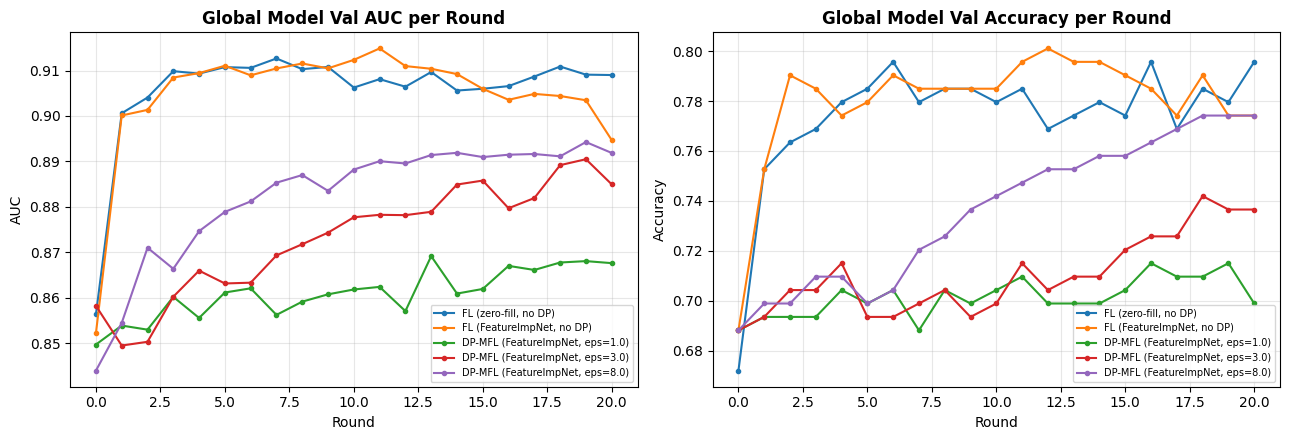

In [38]:
# Global model convergence graph (subtype task, right after FL/DP-MFL training)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, res in results.items():
    auc_series = res['history'].metrics_centralized.get('auc', [])
    acc_series = res['history'].metrics_centralized.get('accuracy', [])
    if auc_series:
        r, v = zip(*auc_series)
        axes[0].plot(r, v, marker='o', ms=3, label=res['name'])
    if acc_series:
        r2, v2 = zip(*acc_series)
        axes[1].plot(r2, v2, marker='o', ms=3, label=res['name'])

axes[0].set_title('Global Model Val AUC per Round', fontweight='bold')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('AUC'); axes[0].grid(alpha=0.3)
axes[1].set_title('Global Model Val Accuracy per Round', fontweight='bold')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Accuracy'); axes[1].grid(alpha=0.3)
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(BASE_DIR / 'global_model_convergence.png', dpi=150)
plt.show()

In [39]:
# Comparison table for all global-model experiments (subtype task)
comparison_rows = []
for key, res in results.items():
    hist = res['history']
    acc_s = hist.metrics_centralized.get('accuracy', [(0, 0.0)])
    auc_s = hist.metrics_centralized.get('auc', [(0, 0.0)])
    f1_s  = hist.metrics_centralized.get('f1', [(0, 0.0)])
    comparison_rows.append({
        'Experiment': res['name'],
        'Imputation': 'No' if 'no_imputation' in key else 'Yes',
        'DP': 'Yes' if key.startswith('dp_mfl') else 'No',
        'Epsilon': f"{res['final_epsilon']:.2f}" if res['final_epsilon'] else '-- N/A',
        'Best Accuracy': round(res['best_accuracy'], 4) if res['best_accuracy'] is not None else None,
        'Best AUC': round(res['best_auc'], 4) if res['best_auc'] is not None else None,
        'Best F1 (macro)': round(res['best_f1'], 4) if res['best_f1'] is not None else None,
        'Final Round Accuracy': round(acc_s[-1][1], 4),
        'Final Round AUC': round(auc_s[-1][1], 4),
        'Final Round F1': round(f1_s[-1][1], 4),
    })

df_global_model_comparison = pd.DataFrame(comparison_rows)
df_global_model_comparison.to_csv(BASE_DIR / 'global_model_comparison.csv', index=False)
df_global_model_comparison   # last line -> Jupyter automatically renders this as an output table

,Experiment,Imputation,DP,Epsilon,Best Accuracy,Best AUC,Best F1 (macro),Final Round Accuracy,Final Round AUC,Final Round F1
0,"FL (zero-fill, no DP)",No,No,-- N/A,0.7957,0.9127,0.6556,0.7957,0.9090,0.6442
1,"FL (FeatureImpNet, no DP)",Yes,No,-- N/A,0.8011,0.9149,0.6293,0.7742,0.8947,0.6057
2,"DP-MFL (FeatureImpNet, eps=1.0)",Yes,Yes,0.21,0.7151,0.8691,0.5788,0.6989,0.8676,0.5331
3,"DP-MFL (FeatureImpNet, eps=3.0)",Yes,Yes,0.62,0.7419,0.8905,0.5807,0.7366,0.8850,0.5167
4,"DP-MFL (FeatureImpNet, eps=8.0)",Yes,Yes,1.78,0.7742,0.8943,0.5788,0.7742,0.8919,0.5543


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [40]:
# pCR LABEL SETUP -- runs before FL pCR training cell
df_final_pcr = df_final.dropna(subset=[PCR_COL]).copy()

pcr_code_raw = pd.to_numeric(df_final_pcr[PCR_COL], errors='coerce')
CODE_TO_LABEL = {1: 1, 2: 0, 3: 0, 4: 0}

df_final_pcr['pcr_label'] = pcr_code_raw.map(CODE_TO_LABEL)
df_final_pcr = df_final_pcr.dropna(subset=['pcr_label']).copy()
df_final_pcr['pcr_label'] = df_final_pcr['pcr_label'].astype(int)

print(f"Kept {len(df_final_pcr)} patients with a usable pCR label")
print(df_final_pcr['pcr_label'].value_counts())

Kept 300 patients with a usable pCR label
pcr_label
0    236
1     64
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [41]:
# ============================================================
# pCR (TREATMENT RESPONSE) -- FULL FEDERATED + DP-MFL TRAINING
# Reuses LocalModel's head_pcr, FeatureImpNet imputation, and the
# same 3-hospital split -- but trains/evaluates the BINARY pCR
# task instead of the 4-class subtype task.
# ============================================================

# ---- 1. Build pCR-labeled per-hospital dataframes ----
def build_pcr_hospital_df(df_h):
    """Keep only patients that have a valid pCR label, preserving row
    positions so imputed-MRI arrays (aligned to df_h's original order)
    can be sliced consistently."""
    mask = df_h[PATIENT_ID_COL].isin(df_final_pcr[PATIENT_ID_COL]).values
    idx_positions = np.where(mask)[0]
    df_h_pcr = df_h.iloc[idx_positions].merge(
        df_final_pcr[[PATIENT_ID_COL, 'pcr_label']], on=PATIENT_ID_COL
    ).reset_index(drop=True)
    return df_h_pcr, idx_positions

df_A_pcr, _posA = build_pcr_hospital_df(df_A)
df_B_pcr, _posB = build_pcr_hospital_df(df_B)
df_C_pcr, _posC = build_pcr_hospital_df(df_C)

imputed_B_pcr = imputed_mri_B[_posB]
imputed_C_pcr = imputed_mri_C[_posC]

print(f"pCR-labeled patients -> A: {len(df_A_pcr)}  B: {len(df_B_pcr)}  C: {len(df_C_pcr)}")
for _name, _d in [('A', df_A_pcr), ('B', df_B_pcr), ('C', df_C_pcr)]:
    print(f"  Hospital {_name}:", _d['pcr_label'].value_counts().to_dict())

def get_full_idx(df_subset):
    """Row positions into df_final -- needed by FederatedDataset to look up
    each patient's EHR/radiomic feature vector."""
    full_ids = df_final[PATIENT_ID_COL].tolist()
    return [full_ids.index(pid) if pid in full_ids else -1
            for pid in df_subset[PATIENT_ID_COL].tolist()]

full_idx_A_pcr = get_full_idx(df_A_pcr)
full_idx_B_pcr = get_full_idx(df_B_pcr)
full_idx_C_pcr = get_full_idx(df_C_pcr)

n_pos = int((df_final_pcr['pcr_label'] == 1).sum())
n_neg = int((df_final_pcr['pcr_label'] == 0).sum())
PCR_POS_WEIGHT = n_neg / max(1, n_pos)
print(f"pCR class balance -> neg:{n_neg} pos:{n_pos}  pos_weight={PCR_POS_WEIGHT:.2f}")


# ---- 2. Federated loaders (same 3-way real/imputed/zero pattern as subtype) ----
def build_pcr_loaders(use_imputation=True, batch_size=BATCH):
    ds_A_pcr_fl = FederatedDataset(df_A_pcr, ehr_final, rad_final, full_idx_A_pcr, PATIENT_ID_COL,
                                    'pcr_label', mri_mode='real', npy_dir=NPY_DIR,
                                    has_ehr=True, has_radiomic=True, transform=train_tf)
    mode_bc = 'imputed' if use_imputation else 'zero'
    ds_B_pcr_fl = FederatedDataset(df_B_pcr, ehr_final, rad_final, full_idx_B_pcr, PATIENT_ID_COL,
                                    'pcr_label', mri_mode=mode_bc, imputed_mri=imputed_B_pcr,
                                    has_ehr=True, has_radiomic=True, transform=val_tf)
    ds_C_pcr_fl = FederatedDataset(df_C_pcr, ehr_final, rad_final, full_idx_C_pcr, PATIENT_ID_COL,
                                    'pcr_label', mri_mode=mode_bc, imputed_mri=imputed_C_pcr,
                                    has_ehr=False, has_radiomic=True, transform=val_tf)

    trA, vlA = train_test_split(range(len(ds_A_pcr_fl)), test_size=0.2,
                                 stratify=df_A_pcr['pcr_label'].values, random_state=42)
    trB, vlB = train_test_split(range(len(ds_B_pcr_fl)), test_size=0.2,
                                 stratify=df_B_pcr['pcr_label'].values, random_state=42)
    trC, vlC = train_test_split(range(len(ds_C_pcr_fl)), test_size=0.2,
                                 stratify=df_C_pcr['pcr_label'].values, random_state=42)

    train_loaders = {
        'A': DataLoader(Subset(ds_A_pcr_fl, trA), batch_size=batch_size, shuffle=True,  num_workers=0),
        'B': DataLoader(Subset(ds_B_pcr_fl, trB), batch_size=batch_size, shuffle=True,  num_workers=0),
        'C': DataLoader(Subset(ds_C_pcr_fl, trC), batch_size=batch_size, shuffle=True,  num_workers=0),
    }
    val_loaders = {
        'A': DataLoader(Subset(ds_A_pcr_fl, vlA), batch_size=batch_size, shuffle=False, num_workers=0),
        'B': DataLoader(Subset(ds_B_pcr_fl, vlB), batch_size=batch_size, shuffle=False, num_workers=0),
        'C': DataLoader(Subset(ds_C_pcr_fl, vlC), batch_size=batch_size, shuffle=False, num_workers=0),
    }
    return train_loaders, val_loaders

print("build_pcr_loaders() ready.")


# ---- 3. Binary eval loop (mirrors eval_loader, but sigmoid + BCE) ----
@torch.no_grad()
def eval_loader_pcr(model, loader, criterion):
    model.eval()
    losses, preds, labels, probs = [], [], [], []
    for batch in loader:
        mri, ehr, rad = batch['mri'].to(device), batch['ehr'].to(device), batch['radiomic'].to(device)
        mri = precompute_mri(mri) 
        mask, lbl = batch['modality_mask'].to(device), batch['label'].to(device).float()
        logits, _ = model(mri, ehr, rad, mask, task='pcr')
        logits = logits.squeeze(1)
        loss = criterion(logits, lbl)
        losses.append(loss.item())
        p = torch.sigmoid(logits)
        probs.extend(p.cpu().numpy())
        preds.extend((p > 0.5).long().cpu().numpy())
        labels.extend(lbl.cpu().numpy())

    labels_np, preds_np, probs_np = np.array(labels), np.array(preds), np.array(probs)
    acc = float(np.mean(preds_np == labels_np)) if len(labels_np) else 0.0
    try:
        auc = float(roc_auc_score(labels_np, probs_np)) if len(np.unique(labels_np)) > 1 else 0.0
    except Exception:
        auc = 0.0
    try:
        f1 = float(f1_score(labels_np, preds_np, zero_division=0)) if len(labels_np) else 0.0
    except Exception:
        f1 = 0.0
    mean_loss = float(np.mean(losses)) if losses else 0.0
    return mean_loss, acc, auc, f1, preds, labels, probs


# ---- 4. Flower client for pCR ----
class HospitalClientPCR(fl.client.NumPyClient):
    def __init__(self, cid, train_loader, val_loader, rad_in, ehr_in,
                 use_dp=True, target_epsilon=8.0, target_delta=1e-5,
                 local_epochs=1, total_rounds=10, pos_weight=1.0):
        self.cid = cid
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.use_dp = use_dp
        self.target_epsilon = target_epsilon
        self.target_delta = target_delta
        self.local_epochs = local_epochs
        self.total_rounds = total_rounds

        self.model = make_model(N_CLASSES, rad_in, ehr_in, dp_safe=use_dp)  # head_pcr is already inside LocalModel

        # DP FIX: this client only ever calls forward(task='pcr'), so
        # head_subtype never receives a gradient. Freeze it (mirrors the
        # head_pcr freeze on the subtype-task client) so Opacus's
        # GradSampleModule doesn't expect a per-sample grad for it.
        for p in self.model.head_subtype.parameters():
            p.requires_grad = False

        self.optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=1e-4
        )
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
        self.privacy_engine = PrivacyEngine() if use_dp else None
        self._dp_attached = False
        self.last_epsilon = 0.0

    def get_parameters(self, config):
        return get_params(self.model)

    def fit(self, parameters, config):
        set_params(self.model, parameters)

        if self.use_dp and not self._dp_attached:
            self.model, self.optimizer, self.train_loader = self.privacy_engine.make_private_with_epsilon(
                module=self.model, optimizer=self.optimizer, data_loader=self.train_loader,
                target_epsilon=self.target_epsilon, target_delta=self.target_delta,
                epochs=max(1, self.total_rounds * self.local_epochs), max_grad_norm=1.0,
            )
            self._dp_attached = True

        self.model.train()
        for _ in range(self.local_epochs):
            for batch in self.train_loader:
                mri, ehr, rad = batch['mri'].to(device), batch['ehr'].to(device), batch['radiomic'].to(device)
                mri = precompute_mri(mri)
                mask, lbl = batch['modality_mask'].to(device), batch['label'].to(device).float()
                self.optimizer.zero_grad(set_to_none=True)
                logits, _ = self.model(mri, ehr, rad, mask, task='pcr')
                loss = self.criterion(logits.squeeze(1), lbl)
                loss.backward()
                self.optimizer.step()

        if self.use_dp:
            self.last_epsilon = self.privacy_engine.get_epsilon(self.target_delta)

        n = len(self.train_loader.dataset)
        return get_params(self.model), n, {'epsilon': float(self.last_epsilon), 'hospital': self.cid}

    def evaluate(self, parameters, config):
        set_params(self.model, parameters)
        loss, acc, auc, f1, preds, labels, probs = eval_loader_pcr(self.model, self.val_loader, self.criterion)
        return float(loss), len(self.val_loader.dataset), {
            'accuracy': acc, 'auc': auc, 'f1': f1, 'hospital': self.cid
        }

print("HospitalClientPCR ready.")


# ---- 5. Server-side global evaluation for pCR ----
def get_evaluate_fn_pcr(val_loaders, rad_in, ehr_in, dp_safe, param_holder, pos_weight):
    eval_model = make_model(N_CLASSES, rad_in, ehr_in, dp_safe=dp_safe)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))

    def evaluate_fn(server_round, parameters, config):
        set_params(eval_model, parameters)
        param_holder['params'] = parameters

        all_preds, all_labels, all_probs = [], [], []
        total_loss, total_n = 0.0, 0
        for hosp in ['A', 'B', 'C']:
            loss, acc, auc, f1, preds, labels, probs = eval_loader_pcr(eval_model, val_loaders[hosp], criterion)
            n = len(val_loaders[hosp].dataset)
            total_loss += loss * n
            total_n += n
            all_preds.extend(preds); all_labels.extend(labels); all_probs.extend(probs)

        labels_np, preds_np, probs_np = np.array(all_labels), np.array(all_preds), np.array(all_probs)
        global_loss = total_loss / total_n if total_n else 0.0
        global_acc = float(np.mean(preds_np == labels_np)) if len(labels_np) else 0.0
        try:
            global_auc = float(roc_auc_score(labels_np, probs_np)) if len(np.unique(labels_np)) > 1 else 0.0
        except Exception:
            global_auc = 0.0
        try:
            global_f1 = float(f1_score(labels_np, preds_np, zero_division=0)) if len(labels_np) else 0.0
        except Exception:
            global_f1 = 0.0

        print(f"[pCR] Round {server_round:02d} | Loss:{global_loss:.4f} "
              f"Acc:{global_acc:.4f} AUC:{global_auc:.4f} F1:{global_f1:.4f}")
        return global_loss, {'accuracy': global_acc, 'auc': global_auc, 'f1': global_f1}

    return evaluate_fn


# ---- 6. Full FL experiment runner for pCR ----
def run_fl_experiment_pcr(name, use_imputation=True, use_dp=True, target_epsilon=8.0,
                           n_rounds=10, local_epochs=1, batch_size=BATCH):
    print(f"\n{'='*70}\n[pCR] Running experiment: {name}\n{'='*70}")

    train_loaders, val_loaders = build_pcr_loaders(use_imputation=use_imputation, batch_size=batch_size)
    rad_in, ehr_in = rad_final.shape[1], ehr_final.shape[1]
    client_cache = {}

    def client_fn(cid):
        if cid not in client_cache:
            hosp = {'0': 'A', '1': 'B', '2': 'C'}[cid]
            client_cache[cid] = HospitalClientPCR(
                hosp, train_loaders[hosp], val_loaders[hosp], rad_in, ehr_in,
                use_dp=use_dp, target_epsilon=target_epsilon, local_epochs=local_epochs,
                total_rounds=n_rounds, pos_weight=PCR_POS_WEIGHT,
            )
        return client_cache[cid].to_client()

    init_model = make_model(N_CLASSES, rad_in, ehr_in, dp_safe=use_dp)
    param_holder = {}
    strategy = fl.server.strategy.FedAvg(
        fraction_fit=1.0, fraction_evaluate=1.0,
        min_fit_clients=3, min_evaluate_clients=3, min_available_clients=3,
        initial_parameters=fl.common.ndarrays_to_parameters(get_params(init_model)),
        evaluate_fn=get_evaluate_fn_pcr(val_loaders, rad_in, ehr_in, dp_safe=use_dp,
                                         param_holder=param_holder, pos_weight=PCR_POS_WEIGHT),
    )
    client_resources = {'num_cpus': 1, 'num_gpus': 0.3 if torch.cuda.is_available() else 0}

    history = fl.simulation.start_simulation(
        client_fn=client_fn, num_clients=3,
        config=fl.server.ServerConfig(num_rounds=n_rounds),
        strategy=strategy, client_resources=client_resources,
        ray_init_args={'ignore_reinit_error': True, 'include_dashboard': False,
                        '_temp_dir': '/tmp/ray_pcr', 'log_to_driver': False},
    )

    global_model = make_model(N_CLASSES, rad_in, ehr_in, dp_safe=use_dp)
    if 'params' in param_holder:
        set_params(global_model, param_holder['params'])
    global_model.eval()

    final_eps = [c.last_epsilon for c in client_cache.values()] if use_dp else [0.0]
    return {'name': name, 'history': history,
            'final_epsilon': max(final_eps) if final_eps else 0.0,
            'global_model': global_model}


# ---- 7. Run the pCR experiments (same ablation structure as subtype) ----
N_ROUNDS_PCR = 10
LOCAL_EPOCHS_PCR = 3

results_pcr = {}

results_pcr['fl_no_imputation_no_dp'] = run_fl_experiment_pcr(
    'pCR FL (zero-fill, no DP)', use_imputation=False, use_dp=False,
    n_rounds=N_ROUNDS_PCR, local_epochs=LOCAL_EPOCHS_PCR)

results_pcr['fl_imputation_no_dp'] = run_fl_experiment_pcr(
    'pCR FL (FeatureImpNet, no DP)', use_imputation=True, use_dp=False,
    n_rounds=N_ROUNDS_PCR, local_epochs=LOCAL_EPOCHS_PCR)

for eps in [1.0, 3.0, 8.0]:
    results_pcr[f'dp_mfl_eps{eps}'] = run_fl_experiment_pcr(
        f'pCR DP-MFL (eps={eps})', use_imputation=True, use_dp=True,
        target_epsilon=eps, n_rounds=N_ROUNDS_PCR, local_epochs=LOCAL_EPOCHS_PCR)

print("\n" + "="*70)
print("ALL pCR EXPERIMENTS FINISHED")
print("="*70)

pCR-labeled patients -> A: 131  B: 93  C: 76
  Hospital A: {0: 102, 1: 29}
  Hospital B: {0: 77, 1: 16}
  Hospital C: {0: 57, 1: 19}
pCR class balance -> neg:236 pos:64  pos_weight=3.69
build_pcr_loaders() ready.
HospitalClientPCR ready.

[pCR] Running experiment: pCR FL (zero-fill, no DP)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-08-29 18:22:05,334	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprec

[pCR] Round 00 | Loss:1.1141 Acc:0.2742 AUC:0.4239 F1:0.3284


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (1, 1.0642723643010663, {'accuracy': 0.5967741935483871, 'auc': 0.510204081632653, 'f1': 0.1935483870967742}, 20.178540672000054)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


[pCR] Round 01 | Loss:1.0643 Acc:0.5968 AUC:0.5102 F1:0.1935


...

INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (10, 1.10643402751415, {'accuracy': 0.7903225806451613, 'auc': 0.5478806907378336, 'f1': 0.0}, 117.21200423300024)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


[pCR] Round 10 | Loss:1.1064 Acc:0.7903 AUC:0.5479 F1:0.0000


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 118.45s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.0579980549312407
INFO :      		round 2: 1.0587175699972338
INFO :      		round 3: 1.061714950107759
INFO :      		round 4: 1.066401525851219
INFO :      		round 5: 1.071332307592515
INFO :      		round 6: 1.0743581542084295
INFO :      		round 7: 1.0821379598590635
INFO :      		round 8: 1.0877768805911463
INFO :      		round 9: 1.0982093637989414
INFO :      		round 10: 1.111087859157593
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.054486745788205
INFO :      		round 1: 1.0574503651549738
INFO :      		round 2: 1.0593754206934283
INFO :      		round 3: 1.0632819917894178
INFO :      		round 4: 1.06795322702777
INFO :      		round 5: 1.0695256581229549
INFO :      		round 6: 1.0769715429313722
INFO :      		round 7: 1.0792590843573693
INFO :      		rou


ALL pCR EXPERIMENTS FINISHED


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [42]:
# ============================================================
# EXTERNAL IMAGE INFERENCE -- pCR (TREATMENT RESPONSE) PREDICTION
# ============================================================
from PIL import Image
import torch.nn.functional as F
import torchvision.transforms as transforms

# 1. Pick which trained pCR global model to use
pcr_global_model = results_pcr['dp_mfl_eps8.0']['global_model']
pcr_global_model = pcr_global_model.to(device)
pcr_global_model.eval()

# 2. Image preprocessing (same as subtype inference)
pcr_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_pcr_from_image(image_path):
    print("=" * 70)
    print("EXTERNAL MRI IMAGE -- TREATMENT RESPONSE (pCR) PREDICTION")
    print("=" * 70)

    image = Image.open(image_path).convert("RGB")
    mri = pcr_transform(image).unsqueeze(0).to(device)
    mri = precompute_mri(mri)          # <-- এই লাইনটা যোগ করো: raw pixel -> 256-d embedding
    # No EHR/Radiomic available for an external image
    ehr = torch.zeros((1, ehr_final.shape[1]), dtype=torch.float32).to(device)
    rad = torch.zeros((1, rad_final.shape[1]), dtype=torch.float32).to(device)
    modality_mask = torch.tensor([[1.0, 0.0, 0.0]], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits, _ = pcr_global_model(mri, ehr, rad, modality_mask, task='pcr')
        prob_pcr = torch.sigmoid(logits).item()   # probability of COMPLETE response

    predicted_label = "Complete Response Expected (pCR)" if prob_pcr > 0.5 \
        else "Incomplete Response Expected (non-pCR)"

    print(f"\nPredicted Treatment Outcome : {predicted_label}")
    print(f"Confidence                  : {max(prob_pcr, 1 - prob_pcr) * 100:.2f}%")
    print(f"P(complete response)        : {prob_pcr * 100:.2f}%")
    print(f"P(incomplete response)      : {(1 - prob_pcr) * 100:.2f}%")
    print("=" * 70)

    return {"prob_complete_response": prob_pcr, "predicted_label": predicted_label}

# 3. Run it on your image
image_path = "/kaggle/input/datasets/nadiajahan24/test-image/test_image.jpg"
prediction = predict_pcr_from_image(image_path)

EXTERNAL MRI IMAGE -- TREATMENT RESPONSE (pCR) PREDICTION

Predicted Treatment Outcome : Complete Response Expected (pCR)
Confidence                  : 64.91%
P(complete response)        : 64.91%
P(incomplete response)      : 35.09%


EXTERNAL MRI IMAGE CLASSIFICATION
Image: /kaggle/input/datasets/nadiajahan24/test-image/test_image.jpg
Original size: (596, 335)


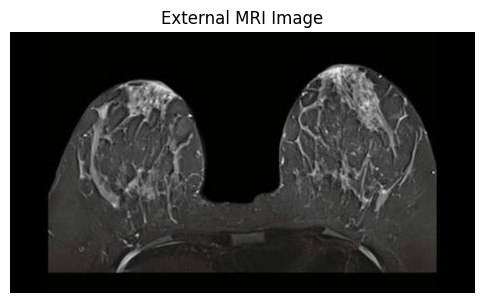


PREDICTION RESULT
Predicted Cancer/Subtype : 2
Confidence               : 63.69%

Class Probabilities:
--------------------------------------------------
0                               19.71%
1                                5.54%
2                               63.69%
3                               11.05%


In [43]:
# ============================================================
# EXTERNAL IMAGE INFERENCE
# PNG / JPG / JPEG -> CANCER SUBTYPE CLASSIFICATION
# ============================================================

from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Select the trained GLOBAL MODEL
# ------------------------------------------------------------

# Change this if you want another experiment's global model
global_model = results['dp_mfl_eps8.0']['global_model']

global_model = global_model.to(device)
global_model.eval()


# ------------------------------------------------------------
# 2. CLASS LABELS
# ------------------------------------------------------------

# IMPORTANT:
# Use the SAME LabelEncoder that was used during training.
class_names = le.classes_


# ------------------------------------------------------------
# 3. IMAGE PREPROCESSING
# ------------------------------------------------------------

external_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# 4. PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_external_image(image_path):

    print("=" * 70)
    print("EXTERNAL MRI IMAGE CLASSIFICATION")
    print("=" * 70)

    # --------------------------------------------------------
    # Load PNG / JPG / JPEG
    # --------------------------------------------------------

    image = Image.open(image_path).convert("RGB")

    print(f"Image: {image_path}")
    print(f"Original size: {image.size}")

    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("External MRI Image")
    plt.show()

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    mri = external_transform(image)
    mri = mri.unsqueeze(0).to(device)
    mri = precompute_mri(mri)          # <-- raw pixel -> 256-d embedding (backbone is Identity in the model)

    # --------------------------------------------------------
    # Missing EHR and Radiomic features
    #
    # Your model expects:
    # MRI + EHR + Radiomic + modality mask
    #
    # Since external input contains only MRI,
    # we represent unavailable modalities accordingly.
    # --------------------------------------------------------

    ehr = torch.zeros(
        (1, ehr_final.shape[1]),
        dtype=torch.float32
    ).to(device)

    rad = torch.zeros(
        (1, rad_final.shape[1]),
        dtype=torch.float32
    ).to(device)

    # --------------------------------------------------------
    # Modality mask
    #
    # MRI available      = 1
    # EHR unavailable    = 0
    # Radiomic unavailable = 0
    #
    # IMPORTANT:
    # Keep the order identical to your training code.
    # --------------------------------------------------------

    modality_mask = torch.tensor(
        [[1.0, 0.0, 0.0]],
        dtype=torch.float32
    ).to(device)

    # --------------------------------------------------------
    # Model inference
    # --------------------------------------------------------

    with torch.no_grad():

        output = global_model(
            mri,
            ehr,
            rad,
            modality_mask
        )

        # Your model currently returns:
        # logits, additional_output

        logits = output[0]

        # ----------------------------------------------------
        # Class probabilities
        # ----------------------------------------------------

        probabilities = F.softmax(
            logits,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item()

    # --------------------------------------------------------
    # Convert class number -> cancer/subtype name
    # --------------------------------------------------------

    predicted_name = class_names[predicted_class]

    # --------------------------------------------------------
    # Display result
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("PREDICTION RESULT")
    print("=" * 70)

    print(
        f"Predicted Cancer/Subtype : {predicted_name}"
    )

    print(
        f"Confidence               : "
        f"{confidence * 100:.2f}%"
    )

    print("\nClass Probabilities:")
    print("-" * 50)

    for i, probability in enumerate(
        probabilities[0].cpu().numpy()
    ):

        print(
            f"{class_names[i]:30s} "
            f"{probability * 100:6.2f}%"
        )

    print("=" * 70)

    return {
        "predicted_class": predicted_class,
        "predicted_name": predicted_name,
        "confidence": confidence,
        "probabilities": probabilities[
            0
        ].cpu().numpy()
    }


# ============================================================
# 5. USE YOUR EXTERNAL IMAGE
# ============================================================

image_path = "/kaggle/input/datasets/nadiajahan24/test-image/test_image.jpg"

prediction = predict_external_image(
    image_path
)

In [44]:
centralized_f1  = f1_score(final_labels, final_preds, average='macro')
centralized_acc = float(np.mean(np.array(final_preds) == np.array(final_labels)))

rows = [{
    'Experiment': 'Centralized (Hospital A, upper bound)',
    'Imputation': '-- N/A', 'DP': 'No', 'Epsilon': '-- N/A',
    'Accuracy': round(centralized_acc, 4),
    'AUC': round(float(best_auc), 4),
    'F1 (macro)': round(float(centralized_f1), 4),
}]

for key, res in results.items():
    hist = res['history']
    acc_s = hist.metrics_centralized.get('accuracy', [(0, 0.0)])
    auc_s = hist.metrics_centralized.get('auc', [(0, 0.0)])
    f1_s  = hist.metrics_centralized.get('f1', [(0, 0.0)])
    rows.append({
        'Experiment': res['name'],
        'Imputation': 'No' if 'no_imputation' in key else 'Yes',
        'DP': 'Yes' if key.startswith('dp_mfl') else 'No',
        'Epsilon': f"{res['final_epsilon']:.2f}" if res['final_epsilon'] else '-- N/A',
        'Accuracy': round(acc_s[-1][1], 4),
        'AUC': round(auc_s[-1][1], 4),
        'F1 (macro)': round(f1_s[-1][1], 4),
    })

df_results = pd.DataFrame(rows)
df_results.to_csv(BASE_DIR / 'final_results_comparison.csv', index=False)
df_results


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Imputation,DP,Epsilon,Accuracy,AUC,F1 (macro)
0,"Centralized (Hospital A, upper bound)",-- N/A,No,-- N/A,0.8919,0.9542,0.7423
1,"FL (zero-fill, no DP)",No,No,-- N/A,0.7957,0.9090,0.6442
2,"FL (FeatureImpNet, no DP)",Yes,No,-- N/A,0.7742,0.8947,0.6057
3,"DP-MFL (FeatureImpNet, eps=1.0)",Yes,Yes,0.21,0.6989,0.8676,0.5331
4,"DP-MFL (FeatureImpNet, eps=3.0)",Yes,Yes,0.62,0.7366,0.8850,0.5167
5,"DP-MFL (FeatureImpNet, eps=8.0)",Yes,Yes,1.78,0.7742,0.8919,0.5543


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


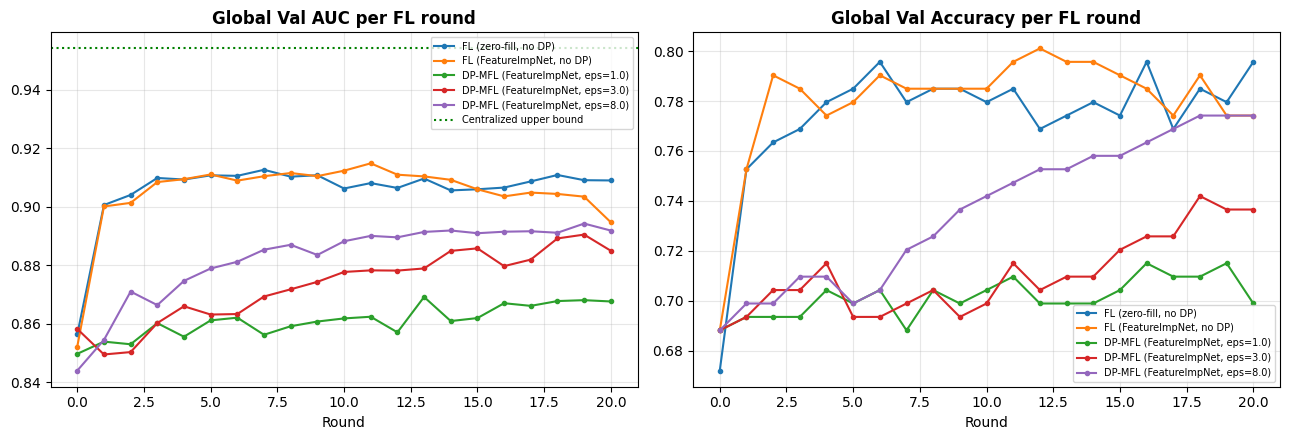

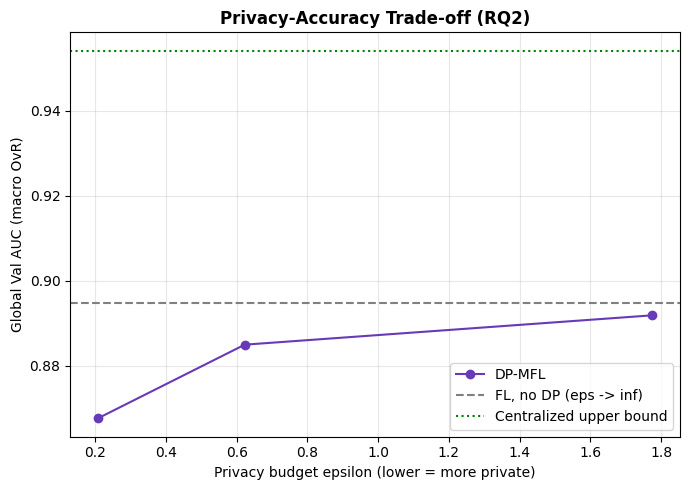

In [45]:
# Round-by-round convergence, all experiments overlaid
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, res in results.items():
    auc_series = res['history'].metrics_centralized.get('auc', [])
    acc_series = res['history'].metrics_centralized.get('accuracy', [])
    if auc_series:
        r, v = zip(*auc_series)
        axes[0].plot(r, v, marker='o', ms=3, label=res['name'])
    if acc_series:
        r2, v2 = zip(*acc_series)
        axes[1].plot(r2, v2, marker='o', ms=3, label=res['name'])
axes[0].axhline(best_auc, color='green', ls=':', label='Centralized upper bound')
axes[0].set_title('Global Val AUC per FL round', fontweight='bold'); axes[0].set_xlabel('Round'); axes[0].grid(alpha=0.3)
axes[1].set_title('Global Val Accuracy per FL round', fontweight='bold'); axes[1].set_xlabel('Round'); axes[1].grid(alpha=0.3)
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(BASE_DIR / 'fl_convergence_curves.png', dpi=150)
plt.show()


# Privacy--accuracy trade-off (RQ2)
eps_vals, aucs = [], []
for eps in [1.0, 3.0, 8.0]:
    r = results[f'dp_mfl_eps{eps}']
    auc_series = r['history'].metrics_centralized.get('auc', [(0, 0.0)])
    eps_vals.append(r['final_epsilon']); aucs.append(auc_series[-1][1])

no_dp_auc = results['fl_imputation_no_dp']['history'].metrics_centralized.get('auc', [(0, 0.0)])[-1][1]
order = np.argsort(eps_vals)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.array(eps_vals)[order], np.array(aucs)[order], 'o-', color='#673AB7', label='DP-MFL')
ax.axhline(no_dp_auc, color='gray', ls='--', label='FL, no DP (eps -> inf)')
ax.axhline(best_auc, color='green', ls=':', label='Centralized upper bound')
ax.set_xlabel('Privacy budget epsilon (lower = more private)')
ax.set_ylabel('Global Val AUC (macro OvR)')
ax.set_title('Privacy-Accuracy Trade-off (RQ2)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / 'privacy_accuracy_tradeoff.png', dpi=150)
plt.show()


In [46]:
# --- Diagnostic: find the real column + its real raw values ---
candidates = [c for c in df_clinical.columns if 'pathologic' in c.lower() and 'response' in c.lower()]
print("Candidate columns:", candidates)

print("\nPCR_COL currently set to:", repr(PCR_COL))
print("Exact match in df_clinical.columns?", PCR_COL in df_clinical.columns)

for c in candidates:
    print(f"\n--- {c!r} ---")
    print(df_clinical[c].value_counts(dropna=False))

Candidate columns: ['Pathologic Response to Neoadjuvant Therapy', 'Pathologic response to Neoadjuvant therapy: Pathologic stage (T) following neoadjuvant therapy ', 'Pathologic response to Neoadjuvant therapy:  Pathologic stage (N) following neoadjuvant therapy', 'Pathologic response to Neoadjuvant therapy:  Pathologic stage (M) following neoadjuvant therapy ']

PCR_COL currently set to: 'Pathologic Response to Neoadjuvant Therapy'
Exact match in df_clinical.columns? True

--- 'Pathologic Response to Neoadjuvant Therapy' ---
Pathologic Response to Neoadjuvant Therapy
NaN                                                                                                                                                                                                                                     610
2                                                                                                                                                                                             

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Raw numeric code counts (before filtering):
Pathologic Response to Neoadjuvant Therapy
2.0    224
1.0     64
5.0     12
3.0     11
4.0      1
Name: count, dtype: int64

Dropped 12 patients (code 5 / unavailable, or the stray legend row)
Kept 300 patients with a usable pCR label
pcr_label
0    236
1     64
Name: count, dtype: int64

Hospital A patients with a pCR label: 131
pcr_label
0    102
1     29
Name: count, dtype: int64

Train: 104 | Val: 27


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


pos_weight (neg/pos in train split): 3.522

Training — Hospital A pCR (centralized baseline)
Ep [  1/40]  Train Loss:1.0805 Acc:0.587  |  Val Loss:1.1234 Acc:0.630 AUC:0.492  <- best


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep [  5/40]  Train Loss:0.9702 Acc:0.721  |  Val Loss:1.0890 Acc:0.593 AUC:0.476


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep [ 35/40]  Train Loss:0.1409 Acc:0.990  |  Val Loss:2.0893 Acc:0.593 AUC:0.429


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep [ 40/40]  Train Loss:0.0724 Acc:1.000  |  Val Loss:2.2488 Acc:0.630 AUC:0.421

Best pCR Val AUC: 0.5238


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


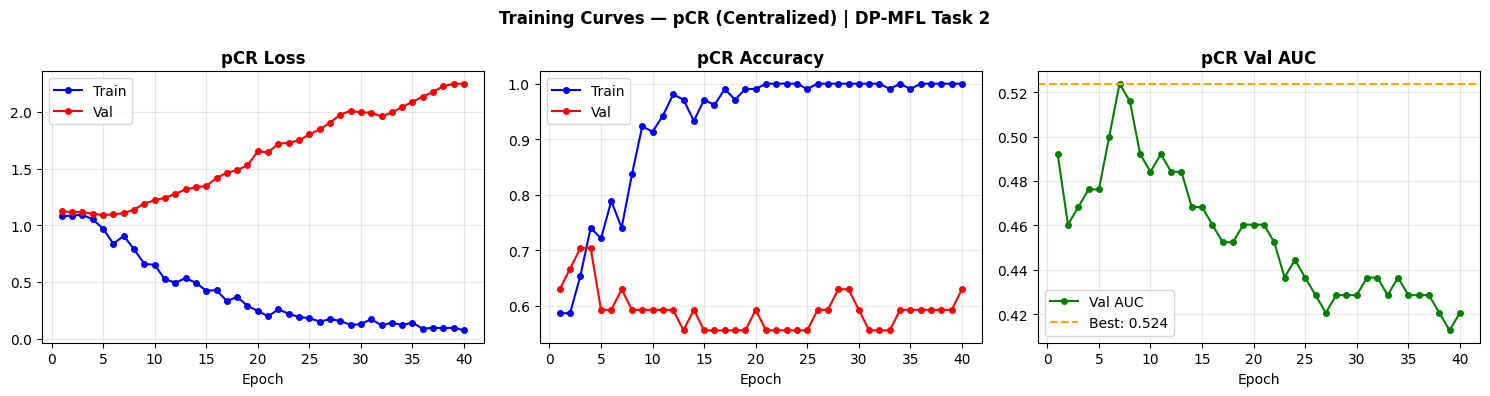


=== Classification Report — centralized pCR Validation ===
                       precision    recall  f1-score   support

not complete response       0.79      0.71      0.75        21
    complete response       0.25      0.33      0.29         6

             accuracy                           0.63        27
            macro avg       0.52      0.52      0.52        27
         weighted avg       0.67      0.63      0.65        27

AUC: 0.5238


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [47]:
# ============================================================
# pCR (Task 2) — Pathologic Complete Response prediction
# Centralized baseline on Hospital A (MRI + EHR + Radiomic)
# ============================================================

df_final_pcr = df_final.dropna(subset=[PCR_COL]).copy()

# This column is NUMERICALLY CODED per the collection's own data dictionary
# (confirmed from a stray legend row that leaked into the raw data column):
#   1 = complete response                          -> pCR positive
#   2 = not complete response                      -> pCR negative
#   3 = DCIS only remaining                        -> pCR negative
#   4 = LCIS only remaining                        -> pCR negative
#   5 = treatment response assessment unavailable  -> drop (unknown outcome)
#  NaN = no neoadjuvant therapy / not enough info  -> already dropped above
# pd.to_numeric(errors='coerce') also turns the stray legend-text row into NaN,
# so it gets dropped along with code 5 instead of crashing / misencoding.

pcr_code_raw = pd.to_numeric(df_final_pcr[PCR_COL], errors='coerce')
print("Raw numeric code counts (before filtering):")
print(pcr_code_raw.value_counts(dropna=False))

CODE_TO_LABEL = {1: 1, 2: 0, 3: 0, 4: 0}   # code 5 and the legend row map to NaN -> dropped

df_final_pcr['pcr_label'] = pcr_code_raw.map(CODE_TO_LABEL)
n_before = len(df_final_pcr)
df_final_pcr = df_final_pcr.dropna(subset=['pcr_label']).copy()
df_final_pcr['pcr_label'] = df_final_pcr['pcr_label'].astype(int)

print(f"\nDropped {n_before - len(df_final_pcr)} patients (code 5 / unavailable, or the stray legend row)")
print(f"Kept {len(df_final_pcr)} patients with a usable pCR label")
print(df_final_pcr['pcr_label'].value_counts())

# --- Restrict to Hospital A (only cohort with real MRI + EHR + Radiomic) ---
df_A_pcr = df_final_pcr[df_final_pcr[PATIENT_ID_COL].isin(df_A[PATIENT_ID_COL])].copy()
print(f"\nHospital A patients with a pCR label: {len(df_A_pcr)}")
print(df_A_pcr['pcr_label'].value_counts())

if len(df_A_pcr) >= 20 and df_A_pcr['pcr_label'].nunique() == 2:

    # --- Dataset / split ---
    ds_A_pcr = BreastCancerDataset(
        df_A_pcr, NPY_DIR, ehr_final, rad_final, PATIENT_ID_COL,
        'pcr_label', df_final, has_mri=True, has_ehr=True, has_radiomic=True,
        transform=val_tf
    )

    trp, vlp = train_test_split(
        range(len(ds_A_pcr)), test_size=0.2,
        stratify=df_A_pcr['pcr_label'].values, random_state=42
    )
    tr_loader_p = DataLoader(Subset(ds_A_pcr, trp), batch_size=BATCH, shuffle=True)
    vl_loader_p = DataLoader(Subset(ds_A_pcr, vlp), batch_size=BATCH, shuffle=False)
    print(f"\nTrain: {len(trp)} | Val: {len(vlp)}")

    # --- Model, optimizer, loss (class-imbalance handled via pos_weight) ---
    pcr_model = LocalModel(n_classes=N_CLASSES, rad_in=rad_final.shape[1], ehr_in=ehr_final.shape[1]).to(device)
    pcr_opt = torch.optim.Adam(pcr_model.parameters(), lr=1e-4, weight_decay=1e-5)
    pcr_scheduler = torch.optim.lr_scheduler.StepLR(pcr_opt, step_size=10, gamma=0.5)

    n_pos = int((df_A_pcr.iloc[trp]['pcr_label'] == 1).sum())
    n_neg = int((df_A_pcr.iloc[trp]['pcr_label'] == 0).sum())
    pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32).to(device)
    pcr_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"pos_weight (neg/pos in train split): {pos_weight.item():.3f}")

    # --- Train / eval loops (Task 2 = pCR, binary sigmoid head) ---
    def train_epoch_pcr(model, loader, optimizer, criterion, device):
        model.train()
        losses, preds_all, labels_all = [], [], []
        for batch in loader:
            mri  = batch['mri'].to(device)
            ehr  = batch['ehr'].to(device)
            rad  = batch['radiomic'].to(device)
            mask = batch['modality_mask'].to(device)
            lbl  = batch['label'].to(device).float()
            optimizer.zero_grad()
            logits, _ = model(mri, ehr, rad, mask, task='pcr')
            loss = criterion(logits.squeeze(1), lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())
            preds_all.extend((torch.sigmoid(logits.squeeze(1)) > 0.5).long().cpu().numpy())
            labels_all.extend(lbl.cpu().numpy())
        acc = np.mean(np.array(preds_all) == np.array(labels_all))
        return np.mean(losses), acc

    @torch.no_grad()
    def eval_epoch_pcr(model, loader, criterion, device):
        model.eval()
        losses, probs_all, labels_all = [], [], []
        for batch in loader:
            mri  = batch['mri'].to(device)
            ehr  = batch['ehr'].to(device)
            rad  = batch['radiomic'].to(device)
            mask = batch['modality_mask'].to(device)
            lbl  = batch['label'].to(device).float()
            logits, _ = model(mri, ehr, rad, mask, task='pcr')
            loss = criterion(logits.squeeze(1), lbl)
            losses.append(loss.item())
            probs_all.extend(torch.sigmoid(logits.squeeze(1)).cpu().numpy())
            labels_all.extend(lbl.cpu().numpy())
        preds = (np.array(probs_all) > 0.5).astype(int)
        acc = np.mean(preds == np.array(labels_all))
        try:
            auc = roc_auc_score(labels_all, probs_all)
        except Exception:
            auc = 0.0
        return np.mean(losses), acc, auc, probs_all, labels_all

    # --- Training loop ---
    PCR_EPOCHS = 40
    pcr_history = {'tr_loss': [], 'vl_loss': [], 'tr_acc': [], 'vl_acc': [], 'vl_auc': []}
    best_pcr_auc = 0.0
    PCR_CKPT = CHECKPOINT_DIR / 'best_pcr_hospitalA.pth'

    print("\nTraining — Hospital A pCR (centralized baseline)")
    for ep in range(1, PCR_EPOCHS + 1):
        tl, ta = train_epoch_pcr(pcr_model, tr_loader_p, pcr_opt, pcr_criterion, device)
        vl, va, vauc, _, _ = eval_epoch_pcr(pcr_model, vl_loader_p, pcr_criterion, device)
        pcr_scheduler.step()

        pcr_history['tr_loss'].append(tl); pcr_history['vl_loss'].append(vl)
        pcr_history['tr_acc'].append(ta);  pcr_history['vl_acc'].append(va)
        pcr_history['vl_auc'].append(vauc)

        if vauc > best_pcr_auc:
            best_pcr_auc = vauc
            torch.save(pcr_model.state_dict(), PCR_CKPT)
            tag = '  <- best'
        else:
            tag = ''

        if ep % 5 == 0 or ep == 1:
            print(f"Ep [{ep:3d}/{PCR_EPOCHS}]  Train Loss:{tl:.4f} Acc:{ta:.3f}  |  Val Loss:{vl:.4f} Acc:{va:.3f} AUC:{vauc:.3f}{tag}")

    print(f"\nBest pCR Val AUC: {best_pcr_auc:.4f}")

    # --- Curves ---
    eps_pcr = range(1, PCR_EPOCHS + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(eps_pcr, pcr_history['tr_loss'], 'b-o', label='Train', ms=4)
    axes[0].plot(eps_pcr, pcr_history['vl_loss'], 'r-o', label='Val', ms=4)
    axes[0].set_title('pCR Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(eps_pcr, pcr_history['tr_acc'], 'b-o', label='Train', ms=4)
    axes[1].plot(eps_pcr, pcr_history['vl_acc'], 'r-o', label='Val', ms=4)
    axes[1].set_title('pCR Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(eps_pcr, pcr_history['vl_auc'], 'g-o', label='Val AUC', ms=4)
    axes[2].axhline(best_pcr_auc, color='orange', ls='--', label=f'Best: {best_pcr_auc:.3f}')
    axes[2].set_title('pCR Val AUC', fontweight='bold'); axes[2].legend(); axes[2].grid(alpha=0.3)
    for ax in axes:
        ax.set_xlabel('Epoch')
    plt.suptitle('Training Curves — pCR (Centralized) | DP-MFL Task 2', fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'pcr_training_curves.png', dpi=150)
    plt.show()

    # --- Final report ---
    pcr_model.load_state_dict(torch.load(PCR_CKPT))
    _, _, _, final_probs_pcr, final_labels_pcr = eval_epoch_pcr(pcr_model, vl_loader_p, pcr_criterion, device)
    final_preds_pcr = (np.array(final_probs_pcr) > 0.5).astype(int)
    print("\n=== Classification Report — centralized pCR Validation ===")
    print(classification_report(final_labels_pcr, final_preds_pcr, target_names=['not complete response', 'complete response']))
    print(f"AUC: {roc_auc_score(final_labels_pcr, final_probs_pcr):.4f}")

else:
    print("Not enough labeled pCR patients / class balance in Hospital A for a reliable run.")
    print("Try increasing N_PATIENTS (up to 922, the full collection) so Hospital A gets more pCR-labeled cases.")

In [48]:
print("Artifacts written to:", BASE_DIR)
for f in sorted(BASE_DIR.glob('*.png')) + sorted(BASE_DIR.glob('*.csv')):
    print(' -', f.name)


Artifacts written to: /kaggle/working/duke_breast_cancer
 - feature_imp_net_curves.png
 - fl_convergence_curves.png
 - global_model_convergence.png
 - hospital_splits.png
 - imputed_attention_weights.png
 - pcr_training_curves.png
 - privacy_accuracy_tradeoff.png
 - sample_preprocessing.png
 - training_curves.png
 - final_results_comparison.csv
 - global_model_comparison.csv
 - preprocessing_log.csv
 - selected_patients.csv
 - selected_series.csv
 - series_list.csv


In [51]:
def _get_working_mri_model(preferred_model=None):
    """
    Tests whether a model's MRI branch produces a valid (B, 256) embedding.
    Falls back through a priority list of known-good models if broken
    (this happens with DP-trained models because ModuleValidator.fix()
    replaces BatchNorm -> GroupNorm even inside the frozen EfficientNet
    backbone, which breaks its forward pass).
    """
    test_mri = torch.zeros((1, 3, 224, 224), dtype=torch.float32).to(device)

    candidates = []
    if preferred_model is not None:
        candidates.append(('preferred', preferred_model))
    # priority fallback order: no-DP FL models first, then centralized
    for key in ['fl_imputation_no_dp', 'fl_zero_fill_no_dp', 'dp_mfl_eps3.0', 'dp_mfl_eps1.0']:
        if key in results:
            candidates.append((key, results[key]['global_model']))
    if 'model' in globals():
        candidates.append(('centralized', model))

    for name, m in candidates:
        try:
            m = m.to(device).eval()
            with torch.no_grad():
                feat = m.mri_enc(test_mri)
            if feat.shape[-1] == 256:   # expected embedding dim
                print(f"[info] using '{name}' model (MRI branch OK, shape {tuple(feat.shape)})")
                return m
        except Exception:
            continue
    raise RuntimeError("No working model found — MRI branch broken in all candidates. "
                        "Restart the kernel and re-run the notebook top to bottom.")


def predict_subtype_from_tabular(ehr_raw_dict, radiomic_raw_dict, model=None):
    """Predict molecular subtype using ONLY EHR + Radiomic (no MRI)."""
    model = _get_working_mri_model(model)

    ehr_t, rad_t = _build_ehr_radiomic_vector(ehr_raw_dict, radiomic_raw_dict)
    mri_t = torch.zeros((1, 3, 224, 224), dtype=torch.float32).to(device)
    modality_mask = torch.tensor([[0.0, 1.0, 1.0]], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits, _ = model(mri_t, ehr_t, rad_t, modality_mask)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    print("=" * 60)
    print("SUBTYPE PREDICTION (EHR + Radiomic only, no MRI)")
    print("=" * 60)
    print(f"Predicted class : {le.classes_[pred_idx]}")
    print(f"Confidence      : {probs[pred_idx]*100:.2f}%")
    for i, c in enumerate(le.classes_):
        print(f"  class {c}: {probs[i]*100:.2f}%")
    return pred_idx, probs


def predict_pcr_from_tabular(ehr_raw_dict, radiomic_raw_dict, model=None):
    """Predict pCR (treatment response) using ONLY EHR + Radiomic (no MRI)."""
    if model is None:
        # pick a working pCR model the same way
        for key in ['fl_no_dp', 'dp_mfl_eps8.0', 'dp_mfl_eps3.0', 'dp_mfl_eps1.0']:
            if key in results_pcr:
                model = results_pcr[key]['global_model']
                break
    model = _get_working_mri_model(model)

    ehr_t, rad_t = _build_ehr_radiomic_vector(ehr_raw_dict, radiomic_raw_dict)
    mri_t = torch.zeros((1, 3, 224, 224), dtype=torch.float32).to(device)
    modality_mask = torch.tensor([[0.0, 1.0, 1.0]], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits, _ = model(mri_t, ehr_t, rad_t, modality_mask, task='pcr')
        prob_pcr = torch.sigmoid(logits).item()

    label = "Complete Response Expected (pCR)" if prob_pcr > 0.5 else "Incomplete Response Expected (non-pCR)"
    print("=" * 60)
    print("pCR PREDICTION (EHR + Radiomic only, no MRI)")
    print("=" * 60)
    print(f"Predicted outcome : {label}")
    print(f"P(complete response)  : {prob_pcr*100:.2f}%")
    print(f"P(incomplete response): {(1-prob_pcr)*100:.2f}%")
    return prob_pcr

In [54]:
for c in ['ER', 'PR', 'HER2', 'Staging(Tumor Size)# [T]', 
          'Lymphadenopathy or Suspicious Nodes',
          'Metastatic at Presentation (Outside of Lymph Nodes)',
          'Tumor Size (cm)', 'Age at mammo (days)']:
    print(f"\n--- {c} ---")
    print(df_final[c].value_counts(dropna=False).head(10))


--- ER ---
ER
1    686
0    236
Name: count, dtype: int64

--- PR ---
PR
1    598
0    324
Name: count, dtype: int64

--- HER2 ---
HER2
0    759
1    163
Name: count, dtype: int64

--- Staging(Tumor Size)# [T] ---
Staging(Tumor Size)# [T]
1.0    409
2.0    395
3.0     90
4.0     22
NaN      6
Name: count, dtype: int64

--- Lymphadenopathy or Suspicious Nodes ---
Lymphadenopathy or Suspicious Nodes
0    627
1    295
Name: count, dtype: int64

--- Metastatic at Presentation (Outside of Lymph Nodes) ---
Metastatic at Presentation (Outside of Lymph Nodes)
0    893
1     29
Name: count, dtype: int64

--- Tumor Size (cm) ---
Tumor Size (cm)
NC     651
NaN    174
2       11
1.5     11
1       10
3        8
2.5      6
3.5      5
0.6      4
0.7      3
Name: count, dtype: int64

--- Age at mammo (days) ---
Age at mammo (days)
NC     651
NaN    138
0       27
-7      10
-1      10
-5      10
-2       6
-8       5
-4       5
7        4
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [55]:
# ---- বেস: বাকি সব column dataset median/mode দিয়ে fill ----
ehr_raw = {}
for c in ehr_cols:
    if df_final[c].dtype == object:
        ehr_raw[c] = df_final[c].mode()[0]
    else:
        ehr_raw[c] = df_final[c].median()

rad_raw = {c: df_final[c].median() for c in radiomic_cols}

# ---- তুমি নিজে বাস্তব external patient হিসেবে বসাও (ধাপ ১-এর output দেখে সঠিক value বসাও) ----
ehr_raw['ER'] = 0.0                                              # <- ধাপ ১ দেখে ঠিক করো (0/1 নাকি অন্য কিছু)
ehr_raw['PR'] = 0.0
ehr_raw['HER2'] = 1.0
ehr_raw['Tumor Size (cm)'] = 5.3                                 # সেন্টিমিটারে, তোমার ইচ্ছামতো বাস্তবসম্মত মান
ehr_raw['Staging(Tumor Size)# [T]'] = 3                          # T-stage code, ধাপ ১ দেখে
ehr_raw['Lymphadenopathy or Suspicious Nodes'] = 0
ehr_raw['Metastatic at Presentation (Outside of Lymph Nodes)'] = 0
ehr_raw['Age at mammo (days)'] = 47 * 365                        # বছর হলে দিন-এ কনভার্ট করে দিতে হবে (dataset days-এ রাখে)

predict_subtype_from_tabular(ehr_raw, rad_raw)
print()
predict_pcr_from_tabular(ehr_raw, rad_raw)

[info] using 'centralized' model (MRI branch OK, shape (1, 256))
SUBTYPE PREDICTION (EHR + Radiomic only, no MRI)
Predicted class : 1
Confidence      : 89.12%
  class 0: 1.74%
  class 1: 89.12%
  class 2: 5.60%
  class 3: 3.54%

[info] using 'centralized' model (MRI branch OK, shape (1, 256))
pCR PREDICTION (EHR + Radiomic only, no MRI)
Predicted outcome : Complete Response Expected (pCR)
P(complete response)  : 58.42%
P(incomplete response): 41.58%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


0.5842423439025879

In [56]:
# ---- Radiomic: "aggressive" বা "benign-looking" profile-এর দিকে shift করে দেখানো ----
# এটা কোনো নির্দিষ্ট নতুন স্ক্যান না, বরং radiomic feature বাড়ালে/কমালে
# model-এর sensitivity/response দেখানোর জন্য একটা controlled demo।

profile = 'aggressive'   # অথবা 'benign' — বদলে দেখো

rad_raw = {}
for c in radiomic_cols:
    base_val = df_final[c].median()
    std = df_final[c].std()
    if profile == 'aggressive':
        # texture heterogeneity / intensity variance বাড়ানো — সাধারণত aggressive tumor-এ বেশি থাকে
        shift = std * 0.8 if ('variance' in c.lower() or 'entropy' in c.lower() or 'heterogeneity' in c.lower()) else 0
    else:
        shift = -std * 0.5 if ('variance' in c.lower() or 'entropy' in c.lower()) else 0
    rad_raw[c] = base_val + shift

predict_subtype_from_tabular(ehr_raw, rad_raw)

[info] using 'centralized' model (MRI branch OK, shape (1, 256))
SUBTYPE PREDICTION (EHR + Radiomic only, no MRI)
Predicted class : 1
Confidence      : 88.22%
  class 0: 1.34%
  class 1: 88.22%
  class 2: 8.58%
  class 3: 1.85%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(1, array([0.01344056, 0.882236  , 0.08584042, 0.01848302], dtype=float32))